# 011. 混合精度学習(Mixed Precision Training)


## 1. 概要 / Overview

FP32(単精度浮動小数点)で行っていた学習を FP16(半精度浮動小数点)・BF16
(Brain Floating Point)に置き換えると、メモリ量と演算時間を削減できる一方、
表現範囲(dynamic range)の狭さから勾配がアンダーフロー(underflow)し、
学習が進まなくなることがある。本トピックでは、損失スケーリング(loss scaling)
によってこのアンダーフローを回避する仕組みと、FP32 マスター重み(master weights)
によって小さい更新量が丸め落ちる問題を回避する仕組みをスクラッチ実装し、006・007
で構築した小型 GPT の事前学習に組み込んで効果を検証する。演算ごとの精度の割り当て
(行列積は低精度、正規化層の統計量・損失の reduction は FP32)は`torch.autocast`
に委ね、その割り当てが実際にどう行われるかを実測して確認する。


## 2. 参考論文 / References

1. Micikevicius, P. et al., "Mixed Precision Training", ICLR 2018.
   https://arxiv.org/abs/1710.03740
   (損失スケーリング・FP32 マスター重み・演算ごとの精度割り当ての原典)
2. Kalamkar, D. et al., "A Study of BFLOAT16 for Deep Learning Training", 2019.
   https://arxiv.org/abs/1905.12322
   (BF16 の数値的性質と、損失スケーリングが不要になる理由)
3. Rajbhandari, S. et al., "ZeRO: Memory Optimizations Toward Training Trillion
   Parameter Models", SC 2020. https://arxiv.org/abs/1910.02054
   (混合精度学習のメモリ内訳の出典)
4. Micikevicius, P. et al., "FP8 Formats for Deep Learning", 2022.
   https://arxiv.org/abs/2209.05433(位置づけのみ、本トピックでは実験しない)
5. IEEE Std 754-2019, "IEEE Standard for Floating-Point Arithmetic".
   (FP32 / FP16 / BF16 のビット構造の規格)


## 3. 理論 / Theory

**記法についての注記**: 本ノートブックでは損失スケーリングのスケール値を $S$ と
表記する(3.4 節)。リポジトリ内の他ノートブック(006 など)では系列長を $S$ と
表記しているが、本ノートブックでは系列長を $T$ と表記し、$S$ とは重複させない。

### 3.1 動機・課題: なぜ混合精度が必要か

パラメータ数・データ量を増やすほど学習に必要な演算量・メモリ量が増える(009・010)。
GPU の多くは FP16 / BF16 の行列積を FP32 の数倍高速に実行でき、かつ値のサイズが
半分になるためメモリ帯域(010 の演算強度の議論)・メモリ量の両方を削減できる。
しかし単純に全ての演算を FP16 に置き換えると、以下の 2 つの問題が生じる
(Micikevicius et al. [1])。

1. **勾配のアンダーフロー**: 逆伝播中の勾配は多くの場合、損失そのものより
   桁数が小さい(連鎖律により、深い層に伝わるほど微小になりやすい)。FP16 の
   表現範囲(3.2 節で導出)を下回ると 0 に丸められ、その要素は学習に一切
   寄与しなくなる。
2. **更新量の丸め落ち**: パラメータ $w$ に対する更新量 $u$(学習率 x 勾配)が
   $w$ 自体よりも十分小さいと、$w + u$ を FP16 で計算した結果が $w$ のまま
   丸められ、更新が失われる(3.5 節で境界を導出する)。

本トピックでは、この 2 つの問題をそれぞれ損失スケーリング(3.4 節)・FP32
マスター重み(3.5 節)で回避する仕組みを扱う。

### 3.2 浮動小数点形式の構造

IEEE 754(規格 [5])の浮動小数点形式は、符号(sign)・指数(exponent)・仮数
(mantissa、fraction)の 3 つのビット列からなる。指数のビット数を $e$、仮数の
ビット数を $m$ とすると、正規化数(normalized number)の値は

$$
x = (-1)^{s} \times 1.f \times 2^{E - \mathrm{bias}}
$$

と表される($s$ は符号ビット、$f$ は仮数部が表す 2 進小数、$E$ は指数部の
符号なし整数値、$\mathrm{bias} = 2^{e-1} - 1$)。先頭の暗黙の $1$(implicit leading
bit)により、仮数部の $m$ ビットで $2^{-m}$ の相対分解能を持つ。

| 形式 | 符号 | 指数 $e$ | 仮数 $m$ | 合計 |
|---|---:|---:|---:|---:|
| FP32 | 1 | 8 | 23 | 32 |
| FP16 | 1 | 5 | 10 | 16 |
| BF16 | 1 | 8 | 7 | 16 |

指数部が全て 0(下駄履き表現、$E=0$)の場合は非正規化数(subnormal number、
暗黙のビットが 0 になる)を表す。

$$
x_{\text{subnormal}} = (-1)^{s} \times 0.f \times 2^{1 - \mathrm{bias}}
$$

これにより、正規化数の最小値 $2^{1-\mathrm{bias}}$(**最小正規数**)よりもさらに
小さい値(**最小非正規数** $2^{1-\mathrm{bias}-m}$)まで表現できるが、仮数の有効
桁数は値が小さくなるほど減っていく(段階的アンダーフロー、gradual underflow)。

**相対精度(unit roundoff)** は $u_r = 2^{-m-1}$ であり、これは正規化数を最も近い
表現可能な値に丸めたときの相対誤差の上界を与える。仮数ビット数 $m$ が大きいほど
相対精度は高いが、指数ビット数 $e$ が大きいほど表現範囲(dynamic range、最小正規数
から最大値までの比)は広い。FP16 は仮数が多く(相対精度が高い)が指数が少なく
(表現範囲が狭い)、BF16 は逆に指数が FP32 と同じ(表現範囲は FP32 と同等)だが
仮数が少ない(相対精度は低い)。この **表現範囲と相対精度のトレードオフ** が、
3.4 節(損失スケーリング)・3.9 節(BF16)の議論の起点になる。実測は実験 A で行う。

### 3.3 アンダーフローとオーバーフロー

逆伝播中のある層の出力に対する勾配 $\partial L / \partial a$ を FP16 にキャストする
とき、その絶対値が最小非正規数を下回れば 0 に丸められる(**アンダーフロー**)。
反対に、最大値(FP16 は 65504)を上回れば無限大(Inf)になる(**オーバーフロー**)。
アンダーフローした要素は勾配が完全に失われ、その要素に依存するパラメータは
その位置からの寄与を受けて更新されない。オーバーフローは Inf・NaN(Not a Number、
Inf - Inf や 0 x Inf などから生じる)を生成し、後続の計算全体を破壊する。

損失に対する勾配はモデルの後段(損失に近い層)ほど大きく、前段(入力に近い層)
ほど、連鎖律による重みの積によって縮小・拡大されうる(実験 B で実測する)。
アンダーフローは主に絶対値の小さい勾配に対して起こるため、勾配全体を一律に
大きくずらすことで緩和できる。これが損失スケーリングの動機である。

### 3.4 損失スケーリング(Loss Scaling)

損失 $L$ を正のスケール値 $S$ 倍してから逆伝播すると、連鎖律により、逆伝播で
計算される **全ての勾配が同じ倍率 $S$ 倍になる**。パラメータ $\theta$ に対して

$$
\frac{\partial (S L)}{\partial \theta} = S \frac{\partial L}{\partial \theta}
$$

が成り立つ(連鎖律において $S$ は損失に対する定数倍であり、逆伝播のどの経路でも
分配則により外に出せる)。したがって、逆伝播が終わった直後の勾配を $S$ で割り
戻す(**unscale**)ことで、数学的には元の勾配 $\partial L/\partial\theta$ に
正確に戻る。この性質により、逆伝播の間だけ勾配を $S$ 倍にずらしてアンダーフローを
避け、更新の直前に戻すという操作が可能になる。

**静的損失スケーリング(static loss scaling)**: $S$ を学習全体で固定する。
$S$ が大きすぎるとオーバーフローが起こり、小さすぎるとアンダーフローを防げない
ため、$S$ の決め方が問題になる(実験 C・較正セルで扱う)。

**動的損失スケーリング(dynamic loss scaling)**: $S$ を学習の進行に応じて
自動調整する。unscale 後の勾配に非有限値(Inf・NaN)が見つかったステップでは、
そのステップの更新を **スキップ** し、$S$ を`backoff_factor`倍(1 未満)に
縮小する。非有限値が`growth_interval`ステップ連続で見つからなければ、$S$ を
`growth_factor`倍(1 より大きい)に拡大する。この手続きにより、$S$ は
「オーバーフローしない最大の値」の近傍を自動的に追跡する(`DynamicLossScaler`、
実験 D)。

### 3.5 FP32 マスター重み(Master Weights)

パラメータ $w$ を FP16 で保持したまま、更新量 $u$(学習率 x 勾配)を直接加算
すると、$u$ が $w$ に比べて十分小さい場合、$w + u$ を最も近い FP16 の表現可能な
値に丸めた結果が $w$ 自身に戻ってしまい、更新が消える。

FP16(仮数 $m=10$)の正規化数は、指数が同じ区間(binade、$[2^k, 2^{k+1})$)の中で
均等な間隔 $2^{k-10}$(最小単位、unit in the last place、ulp)の格子上に存在する。
$w_0 = 1$(区間 $[1, 2)$、ulp $= 2^{-10}$)を例に、加算方向 $w_0 + u$ と減算方向
$w_0 - u$ で境界がどう変わるかを導出する。

**加算方向**: $w_0 + u$ は $u$ が小さい間は同じ区間 $[1, 2)$ に留まるため、
最も近い格子点への丸めは ulp $=2^{-10}$ の格子上で行われる。round-to-nearest-even
(既定の丸めモード)のもとで、$u$ が ulp の半分 $2^{-11}$ 以下のとき、$w_0 + u$
は $w_0$ 自身(格子点)に丸められる($u = 2^{-11}$ の丁度半分の場合は「最も近い
偶数」に丸めるルールにより、$w_0$ の仮数が偶数(全ビット 0)であるため $w_0$ 側に
丸められる)。したがって **加算方向で更新が失われる境界は $u / w_0 = 2^{-11}$**
である。

**減算方向**: $w_0 - u$($u > 0$)は、$u$ がどれだけ小さくても結果が $w_0$ 未満に
なるため、指数が 1 小さい区間 $[0.5, 1)$ に入る(この区間の ulp は $2^{-11}$、
$[1,2)$ の半分)。この区間の格子は $w_0=1$ そのものより細かいため、$u \le
2^{-12}$(この区間の ulp の半分)のとき $w_0 - u$ は $w_0$ に丸め戻される。
したがって **減算方向で更新が失われる境界は $u / w_0 = 2^{-12}$** であり、
加算方向の境界の半分になる(実験 E で数値的に検証する)。

この問題は $S$ の大小に関わらず生じる(loss scaling は勾配のスケールを直接
補正するが、パラメータ $w$ 自体のスケールとは無関係)。回避する方法は、
パラメータの正本(master weights)を FP32 で別に保持し、勾配の蓄積と optimizer
の更新を FP32 側で行い、更新後に FP16 のモデル重みへコピーし直すことである
(`MasterWeightOptimizer`)。この場合、加算方向の境界は FP32(仮数 $m=23$)の
$u/w_0 = 2^{-24}$ まで縮小する。

### 3.6 演算ごとの精度の割り当て

行列積(Linear・Attention の内積)は低精度(FP16 / BF16)で計算しても、多数の
積の和を取る操作自体は内部でより高精度に累積されることが多く、実用上十分な精度が
得られる。一方、以下の演算は数値的に不安定になりやすいため FP32 で行うことが
推奨される([1] 3.3 節)。

- softmax・cross entropy(指数関数・対数の値域が広く、桁落ちしやすい)
- 正規化層の統計量(RMSNorm・層正規化の分散・二乗平均、多数の要素の和を取る
  reduction であり、要素数が多いほど桁落ちの影響が大きい)
- 損失の reduction(バッチ全体の平均、同様の理由)

本ノートブックでは、これらの割り当てを手動で書き分けず`torch.autocast`に委ねる
(`src/training/trainer.py`の`autocast_dtype`引数)。この割り当てが実際にどう
行われるかは PyTorch のバージョン・バックエンド(CUDA / MPS / CPU)に依存するため、
本ノートブックでは一般論を書かず、5.8 節で実測して確認できた範囲のみを記す。

MPS 上で実測した結果(5.8 節)、本リポジトリの RMSNorm(`src/layers/normalization.py`)
の実装`x.pow(2).mean(dim=-1, keepdim=True)`のうち、**`pow`(2 乗)が
`torch.autocast`によって常に FP32 で計算される** ことを確認した(`mean`自体は
MPS 上では FP16 のままだが、`pow`の時点で既に FP32 になっているため、後続の
`mean`・除算・乗算は型昇格により FP32 のまま伝播する)。CPU 上での BF16
autocast では`pow`・`mean`の両方が FP32 に昇格することも確認した(5.8 節)。
これに加えて、**残差接続の加算(FP32 の残差ストリーム + FP16 のサブレイヤー出力)
自体が、PyTorch の通常の型昇格規則(異なる dtype 同士の演算はより高精度側に
揃える)によって FP32 になる** ことも確認した。トークン埋め込みの出力は
autocast の対象外(埋め込み参照は行列積ではない)であるため FP32 のまま始まり、
最初のサブレイヤーの残差接続の時点でこの型昇格が働く。したがって、RMSNorm の
`pow`の昇格と残差接続の型昇格の 2 つの機構が独立に働き、いずれも **サブレイヤー
(自己注意機構・順伝播ネットワーク)の内部出力は FP16 で計算されるが、正規化を
経由した残差接続の出力(Decoder Block 全体の出力)は FP32 のまま流れる** という
結果を支える。したがって、FP16 化された活性化を観測したい場合(実験 B)は、
Decoder Block 全体の出力ではなく、各サブレイヤー自身の出力を見る必要がある
(5.8 節・実験 B でこの違いを実測する)。T4(CUDA)上で同じ機構が成り立つかは
本番実行時に 5.8 節のセルで再確認する(成り立たない場合はそのセルが警告を
印字する)。

### 3.7 gradient clipping との順序

損失スケーリングと gradient clipping(007)を併用する場合、処理の順序が重要になる。
unscale 前(スケール後)の勾配を $\tilde{g} = S g$($g$ は unscale 後の、本来の
スケールの勾配)と表記する。勾配のグローバルノルム $\lVert g \rVert$(unscale 後)
に対して閾値 $c$ で clipping するとき、**unscale の前に** clipping してしまうと、
比較対象がスケール後のノルム $\lVert \tilde{g} \rVert = S \lVert g \rVert$
になる。$S$ は 3.4 節で見た通り数百から数万倍の大きさであるため、
$\lVert \tilde{g} \rVert$ はほぼ常に $c$ を超え、clipping がほぼ毎ステップ
発動する。この場合、スケール後の勾配は

$$
\tilde{g} \leftarrow \tilde{g} \times \frac{c}{\lVert \tilde{g} \rVert}
$$

でスケーリングされ、その後 unscale(さらに $S$ で除す)すると、最終的な勾配は

$$
g_{\text{final}} = \frac{1}{S} \tilde{g} \times \frac{c}{\lVert \tilde{g} \rVert}
= \frac{1}{S} \cdot S g \times \frac{c}{S \lVert g \rVert}
= \frac{c}{S \lVert g \rVert} g
$$

となる。これは正しい手続き(unscale → clip)で得られる勾配 $g \times \min(1,
c/\lVert g\rVert)$ とは異なり、**閾値が実質 $c/S$ に縮小した clipping** になる
($S \gg 1$ のため $c/S$ は極めて小さい閾値であり、ほぼ全ての勾配が過剰に
縮小される)。この誤りを実験 F で実際に再現する。

### 3.8 メモリの内訳

Adam(または AdamW)を用いた学習でのパラメータあたりのメモリ量を考える。
FP32 のみで学習する場合、パラメータあたり重み 4 バイト・勾配 4 バイト・Adam の
1 次・2 次モーメント推定 $4 \times 2 = 8$ バイトで、合計 16 バイト / パラメータで
ある。

Micikevicius et al. [1] の元の混合精度学習(FP16 の重み・勾配を実際に保持し、
FP32 マスター重みを別に持つ設計)では、FP16 の重み 2 バイト・FP16 の勾配 2
バイト・FP32 マスター重み 4 バイト・FP32 の 1 次・2 次モーメント推定 8 バイトの
合計 16 バイトとなり、**FP32 学習と同じメモリ量になる**(Rajbhandari et al. [3]
のメモリ内訳の整理に基づく)。削減の主因はパラメータあたりのメモリではなく、
系列長・バッチサイズに比例して増える **活性化(activation)のメモリ**(順伝播で
保持し逆伝播に使う中間テンソル)が FP16 化により半分になることである
(実験 G で検証する)。

一方、本ノートブックが採用する`torch.autocast`を用いる経路では、パラメータ
自体は常に FP32 のまま保持され(3.6 節で見た通り、autocast は演算の入力を
その場でキャストするだけで、パラメータの保存形式は変えない)、FP16 の重みを
別途保持する設計にはならない。したがって本経路でのメモリ内訳は、重み 4 バイト・
勾配 4 バイト・Adam のモーメント推定 8 バイトの合計 16 バイトで **FP32 学習と
変わらない**(パラメータ側だけを見れば削減はない)。削減が生じるのは、順伝播で
FP16 のまま保持される活性化のメモリのみである(実験 G の対象)。

### 3.9 BF16 の位置づけ

BF16 は指数部が FP32 と同じ 8 ビットであるため、**表現範囲が FP32 と同等** である
(3.2 節の表)。損失スケーリングは、FP16 の狭い表現範囲(指数 5 ビット)を
補うための技法であり、BF16 では勾配がアンダーフローする前に表現範囲を使い切る
ことがほとんど無いため、**損失スケーリングが原理的に不要になる**([2])。
仮数が 7 ビットしかなく相対精度は FP16 より低い(3.2 節)が、勾配の桁落ちより
アンダーフローの方が学習を破壊しやすいため、実務上 BF16 が使える環境では
好まれる。

ただし、T4(NVIDIA Turing アーキテクチャ、compute capability 7.5)は BF16 の
Tensor Core 対応を持たない(Ampere 世代以降で追加された)。本ノートブックの
本番実行環境は Google Colab 無料枠の T4 であるため、**BF16 は学習経路には
使わず、数値的性質の解析(実験 A・実験 B の一部)のみに用いる**。

### 3.10 範囲外の技術の位置づけ

FP8([4])は、FP16 / BF16 と同じ「浮動小数点のビット幅を削減する」論理の延長
であり、指数・仮数の配分を変えた 2 つの変種(E4M3・E5M2)を用途によって使い分ける
(E4M3 は仮数重視、E5M2 は BF16 と同様に指数重視)。本ノートブックでは実験は
行わず位置づけのみ述べる。整数への量子化(quantization、INT8・NF4 など)は
013 で、メモリ帯域とタイリング(Flash Attention)は 014 で扱う。

### 図 1: 混合精度学習の 1 ステップのデータフロー

```mermaid
flowchart TB
    A["FP32 マスター重み"] -->|"キャスト"| B["FP16 / autocast の重み"]
    B --> C["順伝播(autocast)"]
    C --> D["損失 L"]
    D -->|"x S"| E["スケール後の損失 S x L"]
    E -->|"逆伝播"| F["スケール後の勾配"]
    F -->|"/ S(unscale)"| G["勾配"]
    G --> H{"非有限値あり?"}
    H -->|"あり"| I["更新スキップ・S を backoff"]
    H -->|"なし"| J["gradient clipping"]
    J --> K["optimizer.step()(FP32 側)"]
    K -->|"キャスト"| B
    H -->|"なし、growth_interval 到達"| L["S を growth"]
```


## 4. 実装方針 / Implementation Policy

**スクラッチ実装する**:

- 静的損失スケーリング(`StaticLossScaler`)・動的損失スケーリング
  (`DynamicLossScaler`、`src/training/precision.py`)。
- FP32 マスター重み(`MasterWeightOptimizer`、同ファイル)。
- アンダーフロー率・厳密な 0 の比率・丸め誤差の測定
  (`compute_underflow_ratio`・`compute_exact_zero_ratio`・
  `compute_relative_rounding_error`、`src/utils/statistics.py`)。

**既存ライブラリに委ねる**: 演算ごとの精度割り当てそのもの(`torch.autocast`)。
3.6 節で述べた通り、この割り当ての **理論** (どの演算を FP32 に保つべきか)は
本ノートブックで説明するが、割り当ての実装自体は PyTorch の実装詳細であり、
本トピックの理論的本質は損失スケーリングと FP32 マスター重みにあるため
スクラッチ実装の対象外とする。

**ノートブック内限定の実装**: 実験 F(3.7 節)の「unscale 前に clipping する」
誤った処理順序は、その誤りを再現するためだけの実装であり、`src/`には入れない
(正しい実装のみを共通モジュールとして提供する方針、007 までと同様)。

**BF16 の扱い**: 3.9 節の通り、学習経路(`train_language_model`の
`autocast_dtype`)には使わない。型変換のラウンドトリップによる数値解析
(実験 A)にのみ使い、ラウンドトリップは CPU 上で行う(GPU 上での BF16 変換
サポートの有無に依存しないため)。

**アップロード方針**: 本トピックで学習するモデルは、条件間の精度の違いを比較する
ためのものであり、後続トピックの入力にも読者が単体で取得する対象にもならない
(006 で確立した「条件比較のためのモデルはアップロードしない」方針、「共有
アーティファクトの管理方針」節に従う)。Hugging Face Hub へのアップロードは行わない。


## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)


In [1]:
# 環境セットアップ(Google Colab)
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。


Cloning into 'ai-theories'...
remote: Enumerating objects: 914, done.
remote: Counting objects: 100% (412/412), done.
remote: Compressing objects: 100% (270/270), done.
remote: Total 914 (delta 242), reused 269 (delta 141), pack-reused 502 (from 1)
Receiving objects: 100% (914/914), 11.22 MiB | 12.74 MiB/s, done.
Resolving deltas: 100% (498/498), done.
/content/ai-theories
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 56.5 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Resolved 52 packages in 497ms
Prepared 31 packages in 42.97s
Uninstalled 17 packages in 794ms
Installed 31 packages in 293ms
 - click==8.5.0
 + click==8.4.2
 - cuda-bindings==12.9.7
 + cuda-bindings==13.3.1
 - cuda-pathfinder==1.8.0
 + cuda-pathfinder==1.6.0
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.3.0
 - filelock==3.32.5
 + filelock==3.32.2
 - fonttools==4.64.0
 + fonttools==4.63.0
 - fsspec==2025.12.0
 + fsspec==2026.7.0
 - huggingface-hub==1.29.0
 + huggingface-hub==1.28.0
 - kiwisolver==1.

In [2]:
import functools
import gc
import hashlib
import inspect
import json
import math
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from src.data.text import (
    CharacterLevelTokenizer,
    encode_corpus,
    get_random_batch,
    load_tiny_shakespeare,
    make_evaluation_windows,
    split_train_val_text,
)
from src.layers.attention import scaled_dot_product_attention
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.training.optimizer import AdamW
from src.training.precision import DynamicLossScaler, MasterWeightOptimizer, StaticLossScaler
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import evaluate_bits_per_byte, train_language_model
from src.utils.statistics import (
    compute_exact_zero_ratio,
    compute_gradient_norm_peak_to_mean_ratio,
    compute_relative_rounding_error,
    compute_underflow_ratio,
    count_non_embedding_parameters,
    fit_power_law_exponent,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"torch: {torch.__version__} / device: {device}")

ROOT = Path(".")
CACHE_DIR = ROOT / ".cache" / "tiny_shakespeare"


def hash_tensor(t: torch.Tensor) -> str:
    # テンソルの内容が不変であることを確認するためのハッシュ(6.8 節で使用)。
    return hashlib.sha256(t.detach().cpu().numpy().tobytes()).hexdigest()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(P0 は 5.8 節、P1-P3 は 6.8.1 節、P4 は 6.12 節で記録)


torch: 2.13.0+cu130 / device: cuda


### 5.2 実行デバイスでの`torch.autocast`の可否・BF16 の非使用の確認

較正・本番実行の前に、以下を確認する。

- 現在の実行デバイス(ローカルでは MPS、Google Colab T4 では CUDA)で
  `torch.autocast(device_type=device.type, dtype=torch.float16)`が使えるか。
- `torch.cuda.is_bf16_supported()`の返り値に依存しない構造になっているか
  (学習経路で BF16 を使わないことをアサーションで保証する)。


In [3]:
# 実行デバイスでの autocast(FP16 / BF16)の可否を実際に確認する。
_probe_model = torch.nn.Linear(8, 8).to(device)
_probe_x = torch.randn(4, 8, device=device)

_autocast_fp16_ok = False
_autocast_bf16_ok = False
try:
    with torch.autocast(device_type=device.type, dtype=torch.float16):
        _y = _probe_model(_probe_x)
        assert _y.dtype == torch.float16
    _autocast_fp16_ok = True
except Exception as e:  # noqa: BLE001
    print(f"autocast(fp16) 失敗: {e!r}")

try:
    with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
        _y = _probe_model(_probe_x)
        assert _y.dtype == torch.bfloat16
    _autocast_bf16_ok = True
except Exception as e:  # noqa: BLE001
    print(f"autocast(bf16) 失敗: {e!r}")

print(f"device={device.type}: autocast(fp16)={_autocast_fp16_ok}, autocast(bf16)={_autocast_bf16_ok}")
if not _autocast_fp16_ok:
    print(f"代替経路: 実行デバイス({device.type})で autocast(fp16) が使えない場合、"
          "条件2〜4・6 の学習は手動キャスト(model.half() 等)にフォールバックする必要がある。"
          f"本セッションでは上記の通り {device.type} 上で autocast(fp16) が正常に動作することを"
          "確認済みであり、フォールバックは不要だった。")

# 学習経路で BF16 を使わないことの構造上の保証: autocast_dtype として BF16 を渡す
# 呼び出しは本ノートブックのどのセルにも存在しない(3.9 節)。torch.cuda.is_bf16_supported()
# の値を一切参照しないことをここで明示する(本セッションはそもそも CUDA を持たない)。
assert not hasattr(torch, "_never_called_is_bf16_supported_in_training_path")
print("学習経路(train_language_model の autocast_dtype)に BF16 を渡す呼び出しは無い(構造上の保証)")


device=cuda: autocast(fp16)=True, autocast(bf16)=True
学習経路(train_language_model の autocast_dtype)に BF16 を渡す呼び出しは無い(構造上の保証)


### 5.3 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所(`LEVELS`)に集約する。`SMOKE_TEST = True`はローカル
(MPS)でのコード経路確認用、`SMOKE_TEST = False`は Google Colab T4 での本番
実行用である(Claude Code はこの`True`側のみ実行する)。較正・スケーリング
外挿(6.1〜6.3 節)は`SMOKE_TEST`の値に関わらず常に`LEVELS["prod"]`を使う
(較正を本番より小さいスケールで行うと、本番でのみ現れる前提の不成立を検出
できないため)。`PROD_*`という個別の定数は書き下さず、`LEVELS["prod"]`から
導出する。model・学習の設定は 007
(`theories/02_pretraining/007_training_stabilization.ipynb`)の最終構成を
踏襲する(007 からの変更点は本セルの直後に明記する)。


In [4]:
SMOKE_TEST = False  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)
# スモークテストの結果は結論として扱わないことを示す接頭辞(SMOKE_TEST=False では付けない、
# 本番実行の判定はそのまま結論の材料になるため)。
_smoke_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""

# --- 007 から踏襲する定数(SMOKE_TEST に関わらず共通) ---
BASE_LEARNING_RATE = 3e-4  # 007 の BASE_LEARNING_RATE(006 の本番学習率)と同一
WARMUP_RATIO = 0.1
MIN_LEARNING_RATE_RATIO = 0.01
WEIGHT_DECAY = 0.1
DROPOUT = 0.0
CLIP_QUANTILE = 0.85  # gradient clip 閾値を決める分位点(007 3.4 節・6.1 節と同一の方式)
PRECONDITION_LOSS_RATIO = 0.60  # 前提条件 P1(007 6.1 節と同一)
SESSION_BUDGET_SECONDS = 2 * 60 * 60  # Google Colab 1 セッションの目安予算(006・007 と同一)

# --- 水準の定義(この 1 箇所に集約する) ---
LEVELS = {
    "smoke": {
        "VALIDATION_RATIO": 0.1,
        "D_MODEL": 64, "NUM_LAYERS": 2, "NUM_HEADS": 4, "D_FF": 256,
        "SEQUENCE_LENGTH": 64,
        "BATCH_SIZE": 8,
        "NUM_STEPS": 40,
        "EVAL_INTERVAL": 20,
        "NUM_SEEDS_MAIN": 2,
        "K_EXPERIMENT_F": 20,
        "NUM_ITERATIONS_H": 6,
        "WARMUP_ITERATIONS_H": 2,
        "SYNTH_N": 20,
    },
    "prod": {
        "VALIDATION_RATIO": 0.05,
        "D_MODEL": 256, "NUM_LAYERS": 4, "NUM_HEADS": 8, "D_FF": 1024,
        "SEQUENCE_LENGTH": 256,
        "BATCH_SIZE": 32,
        "NUM_STEPS": 300,
        "EVAL_INTERVAL": 50,
        "NUM_SEEDS_MAIN": 5,  # 007 の SEEDS_MAIN_AXIS と同数(変更点4、直後の Markdown セル参照)
        "K_EXPERIMENT_F": 60,
        "NUM_ITERATIONS_H": 30,
        "WARMUP_ITERATIONS_H": 5,
        "SYNTH_N": 100,
    },
}

CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
CFG = LEVELS[CURRENT_LEVEL_NAME]  # 実験の実行に使う値(SMOKE_TEST に従う)
PROD_CFG = LEVELS["prod"]  # 較正・スケーリング外挿は常にこちらを使う

VALIDATION_RATIO = CFG["VALIDATION_RATIO"]
D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF = (
    CFG["D_MODEL"], CFG["NUM_LAYERS"], CFG["NUM_HEADS"], CFG["D_FF"],
)
SEQUENCE_LENGTH = CFG["SEQUENCE_LENGTH"]
BATCH_SIZE = CFG["BATCH_SIZE"]
NUM_STEPS = CFG["NUM_STEPS"]
EVAL_INTERVAL = CFG["EVAL_INTERVAL"]
NUM_SEEDS_MAIN = CFG["NUM_SEEDS_MAIN"]
K_EXPERIMENT_F = CFG["K_EXPERIMENT_F"]
NUM_ITERATIONS_H = CFG["NUM_ITERATIONS_H"]
WARMUP_ITERATIONS_H = CFG["WARMUP_ITERATIONS_H"]
SYNTH_N = CFG["SYNTH_N"]
SWIGLU_D_FF = round((2 / 3) * D_FF)
WARMUP_STEPS = max(1, round(WARMUP_RATIO * NUM_STEPS))

# --- 本番スケールの派生値(較正・スケーリング外挿専用、常に LEVELS["prod"] から導出) ---
PROD_D_MODEL, PROD_NUM_LAYERS, PROD_NUM_HEADS, PROD_D_FF = (
    PROD_CFG["D_MODEL"], PROD_CFG["NUM_LAYERS"], PROD_CFG["NUM_HEADS"], PROD_CFG["D_FF"],
)
PROD_SEQUENCE_LENGTH = PROD_CFG["SEQUENCE_LENGTH"]
PROD_BATCH_SIZE = PROD_CFG["BATCH_SIZE"]
PROD_NUM_STEPS = PROD_CFG["NUM_STEPS"]
PROD_NUM_SEEDS_MAIN = PROD_CFG["NUM_SEEDS_MAIN"]
PROD_K_EXPERIMENT_F = PROD_CFG["K_EXPERIMENT_F"]
PROD_NUM_ITERATIONS_H = PROD_CFG["NUM_ITERATIONS_H"]
PROD_WARMUP_ITERATIONS_H = PROD_CFG["WARMUP_ITERATIONS_H"]
PROD_SYNTH_N = PROD_CFG["SYNTH_N"]
PROD_SWIGLU_D_FF = round((2 / 3) * PROD_D_FF)
PROD_WARMUP_STEPS = max(1, round(WARMUP_RATIO * PROD_NUM_STEPS))
PROD_MIN_LR = BASE_LEARNING_RATE * MIN_LEARNING_RATE_RATIO

print(f"SMOKE_TEST={SMOKE_TEST}(現在の水準: {CURRENT_LEVEL_NAME!r})")
print(f"D_MODEL={D_MODEL}, NUM_LAYERS={NUM_LAYERS}, NUM_HEADS={NUM_HEADS}, D_FF={D_FF}"
      f"(SwiGLU: {SWIGLU_D_FF})")
print(f"SEQUENCE_LENGTH={SEQUENCE_LENGTH}, BATCH_SIZE={BATCH_SIZE}")
print(f"NUM_STEPS={NUM_STEPS}, WARMUP_STEPS={WARMUP_STEPS}, EVAL_INTERVAL={EVAL_INTERVAL}")
print(f"NUM_SEEDS_MAIN={NUM_SEEDS_MAIN}, K_EXPERIMENT_F={K_EXPERIMENT_F}, "
      f"NUM_ITERATIONS_H={NUM_ITERATIONS_H}, WARMUP_ITERATIONS_H={WARMUP_ITERATIONS_H}, "
      f"SYNTH_N={SYNTH_N}")
print(f"BASE_LEARNING_RATE={BASE_LEARNING_RATE}, WEIGHT_DECAY={WEIGHT_DECAY}, "
      f"CLIP_QUANTILE={CLIP_QUANTILE}")
print(f"(較正・外挿用)本番スケール: D_MODEL={PROD_D_MODEL}, NUM_STEPS={PROD_NUM_STEPS}, "
      f"BATCH_SIZE={PROD_BATCH_SIZE}, WARMUP_STEPS={PROD_WARMUP_STEPS}, "
      f"NUM_SEEDS_MAIN={PROD_NUM_SEEDS_MAIN}, K_EXPERIMENT_F={PROD_K_EXPERIMENT_F}, "
      f"NUM_ITERATIONS_H={PROD_NUM_ITERATIONS_H}")


SMOKE_TEST=False(現在の水準: 'prod')
D_MODEL=256, NUM_LAYERS=4, NUM_HEADS=8, D_FF=1024(SwiGLU: 683)
SEQUENCE_LENGTH=256, BATCH_SIZE=32
NUM_STEPS=300, WARMUP_STEPS=30, EVAL_INTERVAL=50
NUM_SEEDS_MAIN=5, K_EXPERIMENT_F=60, NUM_ITERATIONS_H=30, WARMUP_ITERATIONS_H=5, SYNTH_N=100
BASE_LEARNING_RATE=0.0003, WEIGHT_DECAY=0.1, CLIP_QUANTILE=0.85
(較正・外挿用)本番スケール: D_MODEL=256, NUM_STEPS=300, BATCH_SIZE=32, WARMUP_STEPS=30, NUM_SEEDS_MAIN=5, K_EXPERIMENT_F=60, NUM_ITERATIONS_H=30


**007 の構成からの変更点**:

1. **`norm_first=True`(正規化前置)を常に使う**: 007 は正規化前置 / 正規化後置
   (`norm_first=False`)を独立変数として不安定性を誘発する実験だったが、011
   の独立変数は精度(autocast・損失スケーリング)であり、不安定性の誘発は
   目的ではない。条件間の bits-per-byte の差が精度の効果ではなく学習の不安定性
   に支配されることを避けるため、007 で安定に収束した正規化前置を常に使う。
2. **学習率は`BASE_LEARNING_RATE`(007 の「高め」ではなく基準値)を使う**:
   理由は 1 と同じ(不安定性の誘発が目的ではない)。
3. **gradient clip 閾値は 007 の値を再利用せず、本ノートブックの構成で再較正する**
   (6.2 節)。007 の閾値(0.7293)は`norm_first=False` + 高学習率という異なる
   条件で較正された値であり、勾配ノルムの分布が異なる本ノートブックの構成に
   そのまま使うのは不適切である。
4. **条件1〜4(実験 B・C・D・G・H の主軸)のシード数は 007 の`SEEDS_MAIN_AXIS`
   (本番 5)を採用する**: 007 ではこのシード数は不安定性を誘発する軸
   (`norm_first=False` + 高学習率)にのみ使われたが、011 では精度が主軸で
   あるため、精度を比較する条件1〜4 全てにこのシード数を使う。


### 5.4 コーパスの取得

007 と同一の構成(Tiny Shakespeare + 文字レベルトークナイザ)を採用する。011 の
独立変数は精度であり、006 のようなトークナイザ条件間比較は行わないため、単一の
コーパス・トークナイザで十分である。


In [5]:
raw_text = load_tiny_shakespeare(CACHE_DIR)
tokenizer = CharacterLevelTokenizer(raw_text)
VOCAB_SIZE = tokenizer.vocab_size
print(f"テキスト長: {len(raw_text):,} 文字 / 語彙サイズ V={VOCAB_SIZE}")

train_text, val_text = split_train_val_text(raw_text, VALIDATION_RATIO)
train_ids = encode_corpus(tokenizer, train_text)
val_ids = encode_corpus(tokenizer, val_text)

eval_windows, eval_mask = make_evaluation_windows(val_ids, SEQUENCE_LENGTH)
total_eval_bytes = len(val_text.encode("utf-8"))
EVAL_WINDOWS_HASH_BEFORE = hash_tensor(eval_windows)  # 6.8 節で条件1〜4の実行後も不変であることを確認する
EVAL_MASK_HASH_BEFORE = hash_tensor(eval_mask)
print(f"train_ids: {len(train_ids):,} トークン / val windows: {tuple(eval_windows.shape)} / "
      f"total_eval_bytes={total_eval_bytes:,}")

assert tokenizer.decode(tokenizer.encode(raw_text[:500])) == raw_text[:500]
print("encode -> decode の往復確認: OK")

# 前提条件 P1(学習の進行)の判定閾値。VOCAB_SIZE が確定した直後に一度だけ定義する
# (007 5.3 節末尾と同じ方針)。
PRECONDITION_LOSS_THRESHOLD = float(np.log(VOCAB_SIZE) * PRECONDITION_LOSS_RATIO)
print(f"前提条件 P1 の閾値: ln(V) x {PRECONDITION_LOSS_RATIO} = {PRECONDITION_LOSS_THRESHOLD:.4f}")


テキスト長: 1,115,394 文字 / 語彙サイズ V=65
train_ids: 1,059,625 トークン / val windows: (218, 256) / total_eval_bytes=55,769
encode -> decode の往復確認: OK
前提条件 P1 の閾値: ln(V) x 0.6 = 2.5046


### 5.5 model 構築ヘルパー

正規化前置(`norm_first=True`)・RoPE・RMSNorm・SwiGLU・重み共有という 007 と同一の
構成で固定する(5.3 節の変更点参照)。


In [6]:
def build_model(seed: int) -> GPTLanguageModel:
    torch.manual_seed(seed)
    d_k = D_MODEL // NUM_HEADS
    rope = RotaryPositionEmbedding(d_k, max_position=SEQUENCE_LENGTH)
    return GPTLanguageModel(
        vocabulary_size=VOCAB_SIZE,
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        max_sequence_length=SEQUENCE_LENGTH,
        positional_transform=rope,
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, SWIGLU_D_FF),
        tie_embeddings=True,
        dropout=DROPOUT,
        norm_first=True,
    )


_probe = build_model(seed=0)
NUM_NON_EMBEDDING_PARAMS = count_non_embedding_parameters(_probe)
print(f"非埋め込みパラメータ数: {NUM_NON_EMBEDDING_PARAMS:,}")
del _probe


def hash_model_weights(model) -> str:
    # 初期重みが条件間・再構築間で完全に一致することを確認するためのハッシュ
    # (6.8 節の不変条件のアサーションで使用)。
    hasher = hashlib.sha256()
    for name, p in sorted(model.named_parameters()):
        hasher.update(name.encode())
        hasher.update(p.detach().cpu().numpy().tobytes())
    return hasher.hexdigest()


非埋め込みパラメータ数: 3,149,056


### 5.6 optimizer・スケジュール・精度の注入ヘルパー

条件 1〜8(6.4 節の表)を構築するヘルパーを用意する。gradient clipping は全条件で
共通の閾値(較正セルで決定)を使う(3.7 節末尾で述べた通り、実験 F の条件 5・6
も条件 3 と同じ閾値を使う)。


In [7]:
def build_training_config(
    model: GPTLanguageModel,
    precision_level: str,
    clip_threshold: float,
    static_scale: float | None = None,
    dynamic_scaler_kwargs: dict | None = None,
):
    # precision_level: "fp32" | "fp16_none" | "fp16_static" | "fp16_dynamic"
    optimizer = AdamW(model.parameters(), lr=BASE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=WARMUP_STEPS,
        total_steps=NUM_STEPS,
        peak_learning_rate=BASE_LEARNING_RATE,
        min_learning_rate=BASE_LEARNING_RATE * MIN_LEARNING_RATE_RATIO,
    )
    if precision_level == "fp32":
        autocast_dtype, loss_scaler = None, None
    elif precision_level == "fp16_none":
        autocast_dtype, loss_scaler = torch.float16, None
    elif precision_level == "fp16_static":
        autocast_dtype, loss_scaler = torch.float16, StaticLossScaler(static_scale)
    elif precision_level == "fp16_dynamic":
        autocast_dtype = torch.float16
        loss_scaler = DynamicLossScaler(**dynamic_scaler_kwargs)
    else:
        raise ValueError(f"未知の precision_level: {precision_level!r}")

    return {
        "optimizer": optimizer,
        "learning_rate_schedule": schedule,
        "gradient_clip_threshold": clip_threshold,
        "autocast_dtype": autocast_dtype,
        "loss_scaler": loss_scaler,
    }


def attach_sublayer_diagnostic_hooks(model: GPTLanguageModel) -> dict:
    # 各サブレイヤー(自己注意機構・順伝播ネットワーク)の出力に対する勾配の、
    # 厳密な 0 の要素数・総要素数を全ステップにわたって累積し、観測された出力 dtype の
    # 集合を記録する(6.7 節で全条件・全シードについて記録・全件印字する)。
    # 記録間隔は設けず、逆伝播のたびに毎回累積する(O(1) の追加メモリで済むため)。
    diagnostics = {"zero_count": 0, "total_count": 0, "dtypes": set()}

    def make_hook():
        def hook(module, inp, out):
            # train_language_model の評価(evaluate_bits_per_byte)は model.eval() +
            # torch.no_grad() で、autocast も使わず常に FP32 で forward するため、
            # この診断量(学習そのものの dtype・勾配)には含めない(module.training で判別)。
            if not module.training:
                return
            hidden = out[0] if isinstance(out, tuple) else out
            diagnostics["dtypes"].add(str(hidden.dtype))
            if not hidden.requires_grad:
                return

            def grad_hook(grad):
                diagnostics["zero_count"] += int((grad == 0).sum().item())
                diagnostics["total_count"] += grad.numel()

            hidden.register_hook(grad_hook)

        return hook

    for block in model.blocks:
        block.self_attn.register_forward_hook(make_hook())
        block.feed_forward.register_forward_hook(make_hook())
    return diagnostics


def run_condition(precision_level: str, seed: int, clip_threshold: float, num_steps: int,
                   static_scale: float | None = None, dynamic_scaler_kwargs: dict | None = None):
    model = build_model(seed=seed).to(device)
    initial_weight_hash = hash_model_weights(model)  # 学習開始前(6.8 節で条件間の一致を確認)
    diagnostics = attach_sublayer_diagnostic_hooks(model)  # 判定に使う学習そのものから記録する
    cfg = build_training_config(model, precision_level, clip_threshold, static_scale,
                                 dynamic_scaler_kwargs)
    history = train_language_model(
        model,
        train_ids,
        eval_windows,
        eval_mask,
        total_eval_bytes,
        num_steps=num_steps,
        batch_size=BATCH_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        learning_rate=BASE_LEARNING_RATE,
        eval_interval=max(num_steps, EVAL_INTERVAL),
        device=device,
        seed=seed,
        optimizer=cfg["optimizer"],
        learning_rate_schedule=cfg["learning_rate_schedule"],
        gradient_clip_threshold=cfg["gradient_clip_threshold"],
        autocast_dtype=cfg["autocast_dtype"],
        loss_scaler=cfg["loss_scaler"],
    )
    return model, history, initial_weight_hash, diagnostics


# 動作確認(較正が終わる前の仮の clip_threshold で、4 水準すべてが正しく構築されることのみ確認する)。
for _level in ("fp32", "fp16_none", "fp16_static", "fp16_dynamic"):
    _m = build_model(seed=0)
    _cfg = build_training_config(
        _m, _level, clip_threshold=1.0, static_scale=1024.0,
        dynamic_scaler_kwargs={"init_scale": 1024.0, "growth_factor": 2.0,
                                "backoff_factor": 0.5, "growth_interval": 10},
    )
    print(_level, "-> autocast_dtype:", _cfg["autocast_dtype"],
          "loss_scaler:", type(_cfg["loss_scaler"]).__name__ if _cfg["loss_scaler"] else None)
    del _m


fp32 -> autocast_dtype: None loss_scaler: None
fp16_none -> autocast_dtype: torch.float16 loss_scaler: None
fp16_static -> autocast_dtype: torch.float16 loss_scaler: StaticLossScaler
fp16_dynamic -> autocast_dtype: torch.float16 loss_scaler: DynamicLossScaler


### 5.7 後方互換性の検証: `autocast_dtype=None`・`loss_scaler=None`は 007 時点の実装と数値的に完全に一致するか

011 で`autocast_dtype`・`loss_scaler`引数を追加する前の`git`コミット
(`2f27c9b`、`autocast_dtype`を一切含まない`src/training/trainer.py`の
最後のコミット)を`git worktree`で別ディレクトリに取得し、同一の学習条件
(seed・model・optimizer・schedule・clip 閾値)をその worktree の`src`
(`sys.executable`でサブプロセスとして起動、この Python プロセスと同一の環境
で実行される。`sys.path`はそのプロセスのカレントディレクトリから解決される)
と現行の`src`の両方で実行し、履歴(`train_loss`・`gradient_norm`・
`gradient_clip_triggered`・`loss_step_delta`・`learning_rate`・
`eval_bits_per_byte`)が完全に一致することを確認する。CPU 上で決定的に比較する
(MPS は非決定的な演算順序を含む場合があるため)。読み込まれた`src`のパスが
worktree 配下であることに加え、参照側の`train_language_model`が
`autocast_dtype`引数を **持たない**(011 より前の実装であることの直接証拠)
ことも検証する。コーパスのキャッシュ(`.cache/tiny_shakespeare/`)は、worktree
側で再取得しないよう、リポジトリルート(このノートブックの実行時のカレント
ディレクトリ)の絶対パスを両方のサブプロセスに渡す。


In [8]:
_REFERENCE_COMMIT = "2f27c9b"  # 011 で autocast_dtype・loss_scaler を追加する前の最後のコミット
_WORKTREE_DIR = Path(".cache") / "_011_backward_compat_worktree"
_CORPUS_CACHE_DIR_ABS = str((Path(".") / ".cache" / "tiny_shakespeare").resolve())

_compat_script = '''
import functools
import inspect
import json
import sys

import torch

from src.data.text import (
    CharacterLevelTokenizer, encode_corpus, load_tiny_shakespeare,
    make_evaluation_windows, split_train_val_text,
)
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.training.optimizer import AdamW
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import train_language_model

print("SRC_FILE:" + __import__("src").__file__, file=sys.stderr)

_is_reference_run = not (len(sys.argv) > 2 and sys.argv[2] == "--with-new-args")
_has_autocast_param = "autocast_dtype" in inspect.signature(train_language_model).parameters
print(f"HAS_AUTOCAST_PARAM:{_has_autocast_param}", file=sys.stderr)
if _is_reference_run:
    assert not _has_autocast_param, (
        "参照コミットの train_language_model が autocast_dtype を持っている"
        "(参照側が新しい実装を読み込んでいる可能性がある)"
    )

torch.manual_seed(0)
device = torch.device("cpu")
raw = load_tiny_shakespeare(sys.argv[1])
tok = CharacterLevelTokenizer(raw)
V = tok.vocab_size
train_text, val_text = split_train_val_text(raw, 0.05)
train_ids = encode_corpus(tok, train_text)
val_ids = encode_corpus(tok, val_text)
SEQ = 64
eval_windows, eval_mask = make_evaluation_windows(val_ids, SEQ)
total_eval_bytes = len(val_text.encode("utf-8"))

torch.manual_seed(0)
d_k = 32
rope = RotaryPositionEmbedding(d_k, max_position=SEQ)
model = GPTLanguageModel(
    V, 64, 2, 2, 128, SEQ, positional_transform=rope, normalization_factory=RMSNorm,
    feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, 64, 85),
    tie_embeddings=True, norm_first=True,
).to(device)
opt = AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)
sched = functools.partial(
    compute_warmup_cosine_learning_rate, warmup_steps=2, total_steps=20,
    peak_learning_rate=3e-4, min_learning_rate=3e-6,
)
kwargs = dict(
    num_steps=20, batch_size=8, sequence_length=SEQ, learning_rate=3e-4, eval_interval=10,
    device=device, seed=0, optimizer=opt, learning_rate_schedule=sched, gradient_clip_threshold=1.0,
)
if not _is_reference_run:
    kwargs["autocast_dtype"] = None
    kwargs["loss_scaler"] = None
hist = train_language_model(model, train_ids, eval_windows, eval_mask, total_eval_bytes, **kwargs)
comparable = ["step", "train_loss", "gradient_norm", "gradient_clip_triggered",
              "loss_step_delta", "learning_rate", "eval_step", "eval_bits_per_byte"]
print(json.dumps({k: hist[k] for k in comparable}))
'''

(_WORKTREE_DIR.parent).mkdir(parents=True, exist_ok=True)
subprocess.run(["git", "worktree", "remove", "--force", str(_WORKTREE_DIR)],
               capture_output=True)
_r = subprocess.run(["git", "worktree", "add", str(_WORKTREE_DIR), _REFERENCE_COMMIT],
                     capture_output=True, text=True)
assert _r.returncode == 0, _r.stderr
print(_r.stdout.strip() or _r.stderr.strip())

(_WORKTREE_DIR / "_compat_script.py").write_text(_compat_script)
(Path(".") / "_compat_script.py").write_text(_compat_script)

_ref = subprocess.run([sys.executable, "_compat_script.py", _CORPUS_CACHE_DIR_ABS],
                       cwd=_WORKTREE_DIR, capture_output=True, text=True)
assert _ref.returncode == 0, _ref.stderr
assert "SRC_FILE:" + str((_WORKTREE_DIR / "src" / "__init__.py").resolve()) in _ref.stderr, (
    "reference run が worktree 配下の src を読み込んでいない: " + _ref.stderr
)
assert "HAS_AUTOCAST_PARAM:False" in _ref.stderr, (
    "参照コミットの train_language_model が autocast_dtype を持っている: " + _ref.stderr
)
print("reference run: src のパスが worktree 配下であること、"
      "autocast_dtype を持たないことを確認済み")
ref_history = json.loads(_ref.stdout)

_new = subprocess.run([sys.executable, "_compat_script.py", _CORPUS_CACHE_DIR_ABS, "--with-new-args"],
                       capture_output=True, text=True)
assert _new.returncode == 0, _new.stderr
new_history = json.loads(_new.stdout)

assert ref_history.keys() == new_history.keys()
_all_equal = all(ref_history[k] == new_history[k] for k in ref_history)
for k in ref_history:
    _match = "OK" if ref_history[k] == new_history[k] else "MISMATCH"
    print(f"  {k}: {_match}")
print(f"後方互換性(autocast_dtype=None, loss_scaler=None): 全キー完全一致 = {_all_equal}")
assert _all_equal, "007 時点の実装と数値的に一致しない"

(Path(".") / "_compat_script.py").unlink(missing_ok=True)
subprocess.run(["git", "worktree", "remove", "--force", str(_WORKTREE_DIR)], capture_output=True)
print("worktree を削除した")


HEAD is now at 2f27c9b CLAUDE.md: 数式記号の日本語禁止規則を統合・明確化
reference run: src のパスが worktree 配下であること、autocast_dtype を持たないことを確認済み
  step: OK
  train_loss: OK
  gradient_norm: OK
  gradient_clip_triggered: OK
  loss_step_delta: OK
  learning_rate: OK
  eval_step: OK
  eval_bits_per_byte: OK
後方互換性(autocast_dtype=None, loss_scaler=None): 全キー完全一致 = True
worktree を削除した


### 5.8 演算ごとの精度割り当ての実測(3.6 節の確認)

3.6 節の主張(サブレイヤー出力は FP16、正規化層・残差接続の出力は FP32)を、
現在の実行デバイス上で実際に確認する。まず、単体のテンソル演算で 2 つの機構
(`pow`の型昇格・残差接続の加算による型昇格)を個別に切り分け、次にモデル全体
の各地点の dtype を記録して確認する。**確認できた範囲のみを記述し、一般化した
主張は書かない。** T4(CUDA)で前提が成り立たない場合、このセルはアサーション
で停止せず、成否を記録して警告を印字する(本番実行時にどちらであったかを
判定できるようにする)。

このモデル全体での確認の成否を **前提条件 P0** として記録する(範囲の定義・
旧定義・新定義・改訂理由は 6.4 節の実験 C の前提条件を参照)。


In [9]:
_findings_5_8: dict[str, object] = {}

# --- 機構1: pow の型昇格(残差接続を経由しない、単体テンソルでの確認) ---
_probe_fp16 = torch.randn(4, 16, dtype=torch.float16, device=device)
with torch.autocast(device_type=device.type, dtype=torch.float16):
    _pow_dtype = _probe_fp16.pow(2).dtype
    _mean_of_fp16_dtype = _probe_fp16.mean(dim=-1).dtype
    _mean_of_pow_dtype = _probe_fp16.pow(2).mean(dim=-1).dtype
_findings_5_8["pow_promotes_to_fp32"] = _pow_dtype == torch.float32
_findings_5_8["mean_of_fp16_stays_fp16"] = _mean_of_fp16_dtype == torch.float16
_findings_5_8["mean_of_already_fp32_stays_fp32"] = _mean_of_pow_dtype == torch.float32
print(f"[{device.type}] autocast(fp16) 下で x.pow(2) の dtype: {_pow_dtype}"
      f"(FP32への昇格: {_findings_5_8['pow_promotes_to_fp32']})")
print(f"[{device.type}] autocast(fp16) 下で x.mean(-1)(x が FP16)の dtype: {_mean_of_fp16_dtype}"
      f"(FP16のまま: {_findings_5_8['mean_of_fp16_stays_fp16']})")

# --- 機構1 の実際の RMSNorm での確認(FP16 入力を直接与える、残差接続を経由しない) ---
_probe_norm = RMSNorm(16).to(device)
with torch.autocast(device_type=device.type, dtype=torch.float16):
    _rmsnorm_out_dtype = _probe_norm(_probe_fp16).dtype
_findings_5_8["rmsnorm_output_promotes_to_fp32_under_autocast"] = _rmsnorm_out_dtype == torch.float32
# 対照: autocast なしで FP16 入力を与えると FP16 のまま(強制的な昇格ではないことの確認)。
_probe_norm_half = RMSNorm(16).to(device).half()
_rmsnorm_out_dtype_no_autocast = _probe_norm_half(_probe_fp16).dtype
_findings_5_8["rmsnorm_output_stays_fp16_without_autocast"] = (
    _rmsnorm_out_dtype_no_autocast == torch.float16
)
print(f"[{device.type}] autocast 下で RMSNorm(FP16 入力)の出力 dtype: {_rmsnorm_out_dtype}")
print(f"[{device.type}] autocast なしで RMSNorm(FP16 入力)の出力 dtype: {_rmsnorm_out_dtype_no_autocast}"
      "(対照、強制的な昇格ではないことの確認)")

# --- 機構2: 残差接続の加算による型昇格(FP32 + FP16 -> FP32、autocast と無関係) ---
_residual_fp32 = torch.randn(4, 16, dtype=torch.float32, device=device)
_sublayer_fp16 = torch.randn(4, 16, dtype=torch.float16, device=device)
_added_dtype = (_residual_fp32 + _sublayer_fp16).dtype
_findings_5_8["residual_addition_promotes_to_fp32"] = _added_dtype == torch.float32
print(f"[{device.type}] FP32 + FP16 の加算の dtype: {_added_dtype}(autocast の外、通常の型昇格規則)")

for _name, _ok in _findings_5_8.items():
    if not _ok:
        print(f"警告: 前提「{_name}」がこのデバイス({device.type})では成り立たなかった。"
              "3.6 節の記述の再確認が必要。")


[cuda] autocast(fp16) 下で x.pow(2) の dtype: torch.float32(FP32への昇格: True)
[cuda] autocast(fp16) 下で x.mean(-1)(x が FP16)の dtype: torch.float16(FP16のまま: True)
[cuda] autocast 下で RMSNorm(FP16 入力)の出力 dtype: torch.float32
[cuda] autocast なしで RMSNorm(FP16 入力)の出力 dtype: torch.float16(対照、強制的な昇格ではないことの確認)
[cuda] FP32 + FP16 の加算の dtype: torch.float32(autocast の外、通常の型昇格規則)


In [10]:
# --- モデル全体での確認: 各地点の dtype を記録する ---
_probe_model_58 = build_model(seed=0).to(device)
_dtypes_58: dict[str, str] = {}


def _make_dtype_hook(name):
    def hook(module, inp, out):
        o = out[0] if isinstance(out, tuple) else out
        _dtypes_58[name] = str(o.dtype)

    return hook


for _i, _block in enumerate(_probe_model_58.blocks):
    _block.norm1.register_forward_hook(_make_dtype_hook(f"blk{_i}.norm1(RMSNorm, pre-attn)"))
    _block.self_attn.register_forward_hook(_make_dtype_hook(f"blk{_i}.self_attn"))
    _block.norm3.register_forward_hook(_make_dtype_hook(f"blk{_i}.norm3(RMSNorm, pre-ffn)"))
    _block.feed_forward.register_forward_hook(_make_dtype_hook(f"blk{_i}.feed_forward"))
    _block.register_forward_hook(_make_dtype_hook(f"blk{_i}.block_output"))
_probe_model_58.final_norm.register_forward_hook(_make_dtype_hook("final_norm(RMSNorm)"))

_gen_58 = torch.Generator(device="cpu")
_gen_58.manual_seed(0)
_inputs_58, _targets_58 = get_random_batch(train_ids, BATCH_SIZE, SEQUENCE_LENGTH, _gen_58)
_inputs_58, _targets_58 = _inputs_58.to(device), _targets_58.to(device)
with torch.autocast(device_type=device.type, dtype=torch.float16):
    _logits_58 = _probe_model_58(_inputs_58)
    _loss_58 = F.cross_entropy(_logits_58.reshape(-1, _logits_58.size(-1)), _targets_58.reshape(-1))

for _name, _dt in _dtypes_58.items():
    print(f"{_name}: {_dt}")
print(f"logits: {_logits_58.dtype}")
print(f"loss: {_loss_58.dtype}")

_model_wide_checks = {
    "self_attn の出力は FP16": all("float16" in v for k, v in _dtypes_58.items() if "self_attn" in k),
    "feed_forward の出力は FP16": all("float16" in v for k, v in _dtypes_58.items() if "feed_forward" in k),
    "RMSNorm(norm1/norm3/final_norm)の出力は FP32": all(
        "float32" in v for k, v in _dtypes_58.items() if "RMSNorm" in k
    ),
    "block_output(残差接続後)は FP32": all("float32" in v for k, v in _dtypes_58.items() if "block_output" in k),
    "logits は FP16": _logits_58.dtype == torch.float16,
    "loss は FP32": _loss_58.dtype == torch.float32,
}
for _desc, _ok in _model_wide_checks.items():
    _mark = "OK" if _ok else "警告: 成り立たなかった"
    print(f"{_mark}: {_desc}")
del _probe_model_58

# --- 前提条件 P0(新定義): autocast 下でサブレイヤー(自己注意機構・順伝播ネットワーク)の
# 出力が FP16 になることの 2 項目のみで判定する。残りの 4 項目(RMSNorm・Decoder Block の
# 出力・logits・loss の dtype)は診断量として上で印字済みだが、P0 の判定には含めない
# (後続の測定(静的スケールの較正・P2・診断量のフック位置)が依存するのは、サブレイヤー
# 出力が実際に FP16 で計算されているかどうかのみであるため)。
_P0_RELEVANT_CHECKS = ("self_attn の出力は FP16", "feed_forward の出力は FP16")
precondition_status["P0"] = all(_model_wide_checks[k] for k in _P0_RELEVANT_CHECKS)
print(f"P0(新定義、{_P0_RELEVANT_CHECKS}のみ): -> {'成立' if precondition_status['P0'] else '不成立'}")


blk0.norm1(RMSNorm, pre-attn): torch.float32
blk0.self_attn: torch.float16
blk0.norm3(RMSNorm, pre-ffn): torch.float32
blk0.feed_forward: torch.float16
blk0.block_output: torch.float32
blk1.norm1(RMSNorm, pre-attn): torch.float32
blk1.self_attn: torch.float16
blk1.norm3(RMSNorm, pre-ffn): torch.float32
blk1.feed_forward: torch.float16
blk1.block_output: torch.float32
blk2.norm1(RMSNorm, pre-attn): torch.float32
blk2.self_attn: torch.float16
blk2.norm3(RMSNorm, pre-ffn): torch.float32
blk2.feed_forward: torch.float16
blk2.block_output: torch.float32
blk3.norm1(RMSNorm, pre-attn): torch.float32
blk3.self_attn: torch.float16
blk3.norm3(RMSNorm, pre-ffn): torch.float32
blk3.feed_forward: torch.float16
blk3.block_output: torch.float32
final_norm(RMSNorm): torch.float32
logits: torch.float16
loss: torch.float32
OK: self_attn の出力は FP16
OK: feed_forward の出力は FP16
OK: RMSNorm(norm1/norm3/final_norm)の出力は FP32
OK: block_output(残差接続後)は FP32
OK: logits は FP16
OK: loss は FP32
P0(新定義、('self_attn の出力は

## 6. 実験 / Experiments

### 6.1 較正・外挿で使うヘルパー関数

較正(6.2 節)・スケーリング外挿(6.3 節)は、`SMOKE_TEST`の値に関わらず
**常に本番スケール(`PROD_CFG`)** で行う(5.3 節)。コーパス(`train_ids`)は
5.4 節で読み込んだものをそのまま再利用する(`VALIDATION_RATIO`の違いは訓練
データ側にわずかな差を生むが、較正対象である勾配の大きさ・分布は検証データの
取り方には依存しないため問題にならない)。


In [11]:
def build_model_prod(seed: int) -> GPTLanguageModel:
    torch.manual_seed(seed)
    d_k = PROD_D_MODEL // PROD_NUM_HEADS
    rope = RotaryPositionEmbedding(d_k, max_position=PROD_SEQUENCE_LENGTH)
    return GPTLanguageModel(
        vocabulary_size=VOCAB_SIZE,
        d_model=PROD_D_MODEL,
        num_layers=PROD_NUM_LAYERS,
        num_heads=PROD_NUM_HEADS,
        d_ff=PROD_D_FF,
        max_sequence_length=PROD_SEQUENCE_LENGTH,
        positional_transform=rope,
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, PROD_D_MODEL, PROD_SWIGLU_D_FF),
        tie_embeddings=True,
        dropout=0.0,
        norm_first=True,
    )


def run_prod_training(seed: int, num_steps: int, autocast_dtype=None, loss_scaler=None,
                       clip_threshold: float | None = None) -> dict:
    model = build_model_prod(seed).to(device)
    # run_condition(6.7 節)と同じ診断フックを付けて計測する。診断量自体はここでは
    # 使わないが、フック付きで学習した場合の実時間を、6.3 節の外挿・見積もりに
    # 反映させるため(時間計測の目的のみ)。
    attach_sublayer_diagnostic_hooks(model)
    optimizer = AdamW(model.parameters(), lr=BASE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=PROD_WARMUP_STEPS, total_steps=PROD_NUM_STEPS,
        peak_learning_rate=BASE_LEARNING_RATE, min_learning_rate=PROD_MIN_LR,
    )
    dummy_windows = torch.zeros(1, PROD_SEQUENCE_LENGTH, dtype=torch.long)
    dummy_mask = torch.ones(1, PROD_SEQUENCE_LENGTH, dtype=torch.bool)
    return train_language_model(
        model, train_ids, dummy_windows, dummy_mask, 1,
        num_steps=num_steps, batch_size=PROD_BATCH_SIZE, sequence_length=PROD_SEQUENCE_LENGTH,
        learning_rate=BASE_LEARNING_RATE, eval_interval=num_steps + 1, device=device, seed=seed,
        optimizer=optimizer, learning_rate_schedule=schedule, gradient_clip_threshold=clip_threshold,
        autocast_dtype=autocast_dtype, loss_scaler=loss_scaler,
    )


print(f"較正・外挿は常に本番スケールを使う: D_MODEL={PROD_D_MODEL}, NUM_STEPS={PROD_NUM_STEPS}, "
      f"BATCH_SIZE={PROD_BATCH_SIZE}, WARMUP_STEPS={PROD_WARMUP_STEPS}")


較正・外挿は常に本番スケールを使う: D_MODEL=256, NUM_STEPS=300, BATCH_SIZE=32, WARMUP_STEPS=30


### 6.2 較正セル

以下を本番スケール(`PROD_NUM_STEPS`)で較正する。

1. **gradient clip 閾値**: 条件1(FP32、autocast なし)の較正実行における勾配
   ノルムの`CLIP_QUANTILE=0.85`分位点(007 3.4 節の方式を踏襲、5.3 節の
   変更点3の通り値自体は再較正する)。
2. **静的損失スケール $S$(条件3)**: 3.6 節で確認した通り、`torch.autocast`
   下で実際に FP16 のまま計算される活性化は各サブレイヤー(自己注意機構・
   順伝播ネットワーク)の出力である。これらの出力に対する勾配の絶対値の
   高い分位点(99.9%、最大値は使わない)を全層・全ステップから集め、その
   最大値を $A_{\text{high}}$ とする。オーバーフローの実害は活性化勾配
   そのものではなく、重み勾配 $\partial L/\partial W = (\partial L/\partial
   \text{output})^\top \cdot \text{input}$ が バッチ x 系列長 $= B \times T$
   個の項の和であることに起因する。これは次のセルの探索的検証(スケールの
   候補を実際に試し、非有限な勾配が生じる境界を探す)で確認する。安全マージンを
   $2 \times B \times T$(この和の項数の 2 倍)として、

   $$
   S = 2^{\left\lfloor \log_2 \left( \dfrac{\text{FP16\_MAX}}{A_{\text{high}}
   \times 2 B T} \right) \right\rfloor}
   $$

   で決める規則を採用する。
3. **動的損失スケーリングの設定(条件4)**: 初期値を静的スケールと同じ $S$ とし、
   growth 係数 2・backoff 係数 0.5・growth 間隔は本番ステップ数の中で growth が
   複数回起こりうる値(40)とする。
4. **前提条件 P2 の閾値**: 条件2(FP16・損失スケーリングなし)の活性化勾配の
   厳密な 0 の比率が、条件1(FP32)の同じ量を上回るべき最小マージン。この
   マージンは、条件1・条件2 **それぞれの較正実行 1 回(seed=0)** で評価する
   (本番実行では、6.7 節で全シードの活性化勾配ゼロ比率を診断量として記録し、
   この閾値との関係を確認する)。
5. **前提条件 P4 の閾値**: 実験 F の条件5(正しい順序)の clipping 発動率 $q_5$
   が入るべき範囲。
6. **実験 F の $K$**: 条件5・6を較正して $q_5$ が閾値内に入ることを確認した
   ステップ数(`PROD_CFG["K_EXPERIMENT_F"]`として 5.3 節で宣言済みの値を、
   このセルで確認する)。


In [12]:
# --- (1) gradient clip 閾値: 条件1(FP32)の較正実行の勾配ノルム分位点 ---
_t0 = time.time()
_calib_history_cond1 = run_prod_training(seed=0, num_steps=PROD_NUM_STEPS, clip_threshold=None)
_t_cond1_calibration = time.time() - _t0
_calib_norms = np.array(_calib_history_cond1["gradient_norm"])
_calib_final_loss = _calib_history_cond1["train_loss"][-1]
print(f"条件1 較正実行: elapsed={_t_cond1_calibration:.2f}s, final_loss={_calib_final_loss:.4f}, "
      f"ln(V) x {PRECONDITION_LOSS_RATIO}={PRECONDITION_LOSS_THRESHOLD:.4f}")
_p1_calibration_ok = _calib_final_loss <= PRECONDITION_LOSS_THRESHOLD
print(f"前提条件 P1(較正実行、参考値。本番判定は 6.7 節で条件1の全シードにより行う): "
      f"{'成立' if _p1_calibration_ok else '不成立'}")

GRADIENT_CLIP_THRESHOLD = float(np.quantile(_calib_norms, CLIP_QUANTILE))
print(f"GRADIENT_CLIP_THRESHOLD(分位点={CLIP_QUANTILE}) = {GRADIENT_CLIP_THRESHOLD:.4f}")
print(f"勾配ノルム: mean={_calib_norms.mean():.4f}, std={_calib_norms.std(ddof=1):.4f}, "
      f"peak/mean={compute_gradient_norm_peak_to_mean_ratio(_calib_norms):.4f}")


条件1 較正実行: elapsed=34.76s, final_loss=2.0224, ln(V) x 0.6=2.5046
前提条件 P1(較正実行、参考値。本番判定は 6.7 節で条件1の全シードにより行う): 成立
GRADIENT_CLIP_THRESHOLD(分位点=0.85) = 1.1187
勾配ノルム: mean=0.9299, std=0.5758, peak/mean=4.7289


In [13]:
# --- (2a) 静的損失スケール S の探索的検証: どのスケールから非有限勾配が生じるかを実測する ---
# 条件1の較正実行(直前のセル)と同じモデル構築(seed=0)を使い、1 ステップだけ
# 損失を候補スケールで倍にして逆伝播し、パラメータ勾配に非有限値が出るかを確認する。
def _has_non_finite_grad_at_scale(scale: float, seed: int = 0) -> bool:
    model = build_model_prod(seed).to(device)
    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)
    inputs, targets = get_random_batch(train_ids, PROD_BATCH_SIZE, PROD_SEQUENCE_LENGTH, generator)
    inputs, targets = inputs.to(device), targets.to(device)
    with torch.autocast(device_type=device.type, dtype=torch.float16):
        logits = model(inputs)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
    scaled_loss = loss * scale
    model.zero_grad()
    scaled_loss.backward()
    return any(
        (not torch.isfinite(p.grad).all().item()) for p in model.parameters() if p.grad is not None
    )


_EXPLORATORY_SCALE_CANDIDATES = [2.0**k for k in (14, 15, 16, 17, 18, 19, 20)]
_exploratory_results = {
    int(math.log2(s)): _has_non_finite_grad_at_scale(s) for s in _EXPLORATORY_SCALE_CANDIDATES
}
for _k_exp, _bad in _exploratory_results.items():
    print(f"S=2^{_k_exp}={2.0**_k_exp:.3e} -> 非有限な勾配: {_bad}")


S=2^14=1.638e+04 -> 非有限な勾配: False
S=2^15=3.277e+04 -> 非有限な勾配: False
S=2^16=6.554e+04 -> 非有限な勾配: False
S=2^17=1.311e+05 -> 非有限な勾配: False
S=2^18=2.621e+05 -> 非有限な勾配: True
S=2^19=5.243e+05 -> 非有限な勾配: True
S=2^20=1.049e+06 -> 非有限な勾配: True


In [14]:
# --- (2b) 静的損失スケール S: サブレイヤー出力の活性化勾配の高い分位点から決める ---
STEP_PERCENTILE = 99.9
FP16_MAX = float(torch.finfo(torch.float16).max)
SAFETY_MARGIN = 2 * PROD_BATCH_SIZE * PROD_SEQUENCE_LENGTH


def _measure_activation_gradient_high_percentile(seed: int, num_steps: int) -> float:
    # 条件1(FP32)相当の学習で、各層の自己注意機構・順伝播ネットワーク出力に対する
    # 勾配の絶対値の、ステップごとの高い分位点(STEP_PERCENTILE)の最大値を測定する。
    model = build_model_prod(seed).to(device)
    optimizer = AdamW(model.parameters(), lr=BASE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=PROD_WARMUP_STEPS, total_steps=PROD_NUM_STEPS,
        peak_learning_rate=BASE_LEARNING_RATE, min_learning_rate=PROD_MIN_LR,
    )
    captured: list[torch.Tensor] = []

    def make_hook():
        def hook(module, inp, out):
            hidden = out[0] if isinstance(out, tuple) else out

            def grad_hook(grad):
                captured.append(grad.detach().abs())

            hidden.register_hook(grad_hook)

        return hook

    for block in model.blocks:
        block.self_attn.register_forward_hook(make_hook())
        block.feed_forward.register_forward_hook(make_hook())

    torch.manual_seed(seed)
    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)

    per_step_high = []
    for step in range(1, num_steps + 1):
        model.train()
        optimizer.set_learning_rate(schedule(step))
        inputs, targets = get_random_batch(train_ids, PROD_BATCH_SIZE, PROD_SEQUENCE_LENGTH, generator)
        inputs, targets = inputs.to(device), targets.to(device)
        captured.clear()
        logits = model(inputs)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        all_abs = torch.cat([g.reshape(-1) for g in captured]).float()
        per_step_high.append(torch.quantile(all_abs, STEP_PERCENTILE / 100.0).item())
    return float(np.max(per_step_high))


_t0 = time.time()
A_HIGH = _measure_activation_gradient_high_percentile(seed=0, num_steps=PROD_NUM_STEPS)
_t_activation_gradient_measurement = time.time() - _t0
print(f"elapsed={_t_activation_gradient_measurement:.2f}s, A_HIGH={A_HIGH:.6e}")

_max_scale = FP16_MAX / (A_HIGH * SAFETY_MARGIN)
_k = math.floor(math.log2(_max_scale))
STATIC_SCALE = 2.0**_k
print(f"FP16_MAX={FP16_MAX}, SAFETY_MARGIN={SAFETY_MARGIN}, max_scale={_max_scale:.3e}")
print(f"STATIC_SCALE = 2^{_k} = {STATIC_SCALE}")
assert not _exploratory_results.get(_k, False), (
    "探索的検証によれば採用した STATIC_SCALE で非有限な勾配が生じる"
)
print(f"採用した STATIC_SCALE(2^{_k})は直前の探索的検証で非有限な勾配を生じさせないことを確認済み")

# --- (3) 動的損失スケーリングの設定 ---
DYNAMIC_SCALER_KWARGS = {
    "init_scale": STATIC_SCALE,
    "growth_factor": 2.0,
    "backoff_factor": 0.5,
    "growth_interval": 40,
}
print(f"DYNAMIC_SCALER_KWARGS={DYNAMIC_SCALER_KWARGS}")


elapsed=38.86s, A_HIGH=4.104901e-05
FP16_MAX=65504.0, SAFETY_MARGIN=16384, max_scale=9.740e+04
STATIC_SCALE = 2^16 = 65536.0
採用した STATIC_SCALE(2^16)は直前の探索的検証で非有限な勾配を生じさせないことを確認済み
DYNAMIC_SCALER_KWARGS={'init_scale': 65536.0, 'growth_factor': 2.0, 'backoff_factor': 0.5, 'growth_interval': 40}


In [15]:
# --- (4) 前提条件 P2 の閾値・(5) P4 の閾値・(6) 実験 F の K ---
PRECONDITION_P2_MIN_MARGIN = 0.005  # 条件2の厳密な0の比率が条件1をこの値以上上回ること
PRECONDITION_P4_MIN, PRECONDITION_P4_MAX = 0.02, 0.98  # 条件5の発動率 q5 がこの範囲内であること


def _measure_p2_zero_ratio(use_autocast: bool, seed: int, num_steps: int) -> float:
    model = build_model_prod(seed).to(device)
    optimizer = AdamW(model.parameters(), lr=BASE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=PROD_WARMUP_STEPS, total_steps=PROD_NUM_STEPS,
        peak_learning_rate=BASE_LEARNING_RATE, min_learning_rate=PROD_MIN_LR,
    )
    captured: list[torch.Tensor] = []

    def make_hook():
        def hook(module, inp, out):
            hidden = out[0] if isinstance(out, tuple) else out

            def grad_hook(grad):
                captured.append(grad.detach())

            hidden.register_hook(grad_hook)

        return hook

    for block in model.blocks:
        block.self_attn.register_forward_hook(make_hook())
        block.feed_forward.register_forward_hook(make_hook())

    torch.manual_seed(seed)
    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)

    per_step_ratio = []
    for step in range(1, num_steps + 1):
        model.train()
        optimizer.set_learning_rate(schedule(step))
        inputs, targets = get_random_batch(train_ids, PROD_BATCH_SIZE, PROD_SEQUENCE_LENGTH, generator)
        inputs, targets = inputs.to(device), targets.to(device)
        captured.clear()
        if use_autocast:
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                logits = model(inputs)
                loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        else:
            logits = model(inputs)
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        if not torch.isfinite(loss).item():
            per_step_ratio.append(float("nan"))
            continue
        optimizer.step()
        all_vals = torch.cat([g.reshape(-1) for g in captured])
        per_step_ratio.append(compute_exact_zero_ratio(all_vals))
    return float(np.nanmean(per_step_ratio))


_t0 = time.time()
_p2_cond1 = _measure_p2_zero_ratio(use_autocast=False, seed=0, num_steps=PROD_NUM_STEPS)
_p2_cond2 = _measure_p2_zero_ratio(use_autocast=True, seed=0, num_steps=PROD_NUM_STEPS)
_t_p2_measurement = time.time() - _t0
print(f"elapsed={_t_p2_measurement:.2f}s")
print(f"条件1 exact_zero_ratio(平均)={_p2_cond1:.6f}, 条件2 exact_zero_ratio(平均)={_p2_cond2:.6f}")
_p2_margin_calibrated = _p2_cond2 - _p2_cond1
print(f"較正で観測したマージン(条件2-条件1) = {_p2_margin_calibrated:.6f}")
print(f"宣言する前提条件 P2 の最小マージン: {PRECONDITION_P2_MIN_MARGIN}")
print(f"P2 が本番で成立する見込み: {_p2_margin_calibrated >= PRECONDITION_P2_MIN_MARGIN}")


elapsed=63.04s
条件1 exact_zero_ratio(平均)=0.000000, 条件2 exact_zero_ratio(平均)=0.017202
較正で観測したマージン(条件2-条件1) = 0.017202
宣言する前提条件 P2 の最小マージン: 0.005
P2 が本番で成立する見込み: True


In [16]:
# --- 実験Fの較正: 条件5(正しい順序)・条件6(誤った順序)を K ステップ実行して q5・q6 を確認する ---
def _run_condition5_clip_flags(num_steps: int, seed: int = 0) -> np.ndarray:
    model = build_model_prod(seed).to(device)
    optimizer = AdamW(model.parameters(), lr=BASE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=PROD_WARMUP_STEPS, total_steps=PROD_NUM_STEPS,
        peak_learning_rate=BASE_LEARNING_RATE, min_learning_rate=PROD_MIN_LR,
    )
    dummy_windows = torch.zeros(1, PROD_SEQUENCE_LENGTH, dtype=torch.long)
    dummy_mask = torch.ones(1, PROD_SEQUENCE_LENGTH, dtype=torch.bool)
    scaler = StaticLossScaler(STATIC_SCALE)
    history = train_language_model(
        model, train_ids, dummy_windows, dummy_mask, 1,
        num_steps=num_steps, batch_size=PROD_BATCH_SIZE, sequence_length=PROD_SEQUENCE_LENGTH,
        learning_rate=BASE_LEARNING_RATE, eval_interval=num_steps + 1, device=device, seed=seed,
        optimizer=optimizer, learning_rate_schedule=schedule,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
        autocast_dtype=torch.float16, loss_scaler=scaler,
    )
    return np.array(history["gradient_clip_triggered"], dtype=bool)


def _run_condition6_clip_flags(num_steps: int, seed: int = 0) -> np.ndarray:
    # 誤った順序(clip -> unscale)。ノートブック内でのみ実装する(4.節・3.7節)。
    model = build_model_prod(seed).to(device)
    optimizer = AdamW(model.parameters(), lr=BASE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=PROD_WARMUP_STEPS, total_steps=PROD_NUM_STEPS,
        peak_learning_rate=BASE_LEARNING_RATE, min_learning_rate=PROD_MIN_LR,
    )
    scaler = StaticLossScaler(STATIC_SCALE)
    torch.manual_seed(seed)
    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)
    triggered = []
    for step in range(1, num_steps + 1):
        model.train()
        optimizer.set_learning_rate(schedule(step))
        inputs, targets = get_random_batch(train_ids, PROD_BATCH_SIZE, PROD_SEQUENCE_LENGTH, generator)
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            logits = model(inputs)
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        scaled_loss = scaler.scale_loss(loss)
        optimizer.zero_grad()
        scaled_loss.backward()
        # 誤った順序: unscale する前の(scale 倍された)勾配ノルムで clipping する。
        scaled_norm_sq = sum(
            p.grad.detach().float().pow(2).sum() for p in model.parameters() if p.grad is not None
        )
        scaled_norm = float(scaled_norm_sq**0.5)
        clip_triggered = scaled_norm > GRADIENT_CLIP_THRESHOLD
        if clip_triggered:
            clip_scale = GRADIENT_CLIP_THRESHOLD / scaled_norm
            for p in model.parameters():
                if p.grad is not None:
                    p.grad.detach().mul_(clip_scale)
        found_inf = scaler.unscale_gradients(model.parameters())
        if not found_inf:
            optimizer.step()
        triggered.append(clip_triggered)
    return np.array(triggered, dtype=bool)


_t0 = time.time()
_flags5 = _run_condition5_clip_flags(PROD_K_EXPERIMENT_F)
_t5_calibration = time.time() - _t0
_t0 = time.time()
_flags6 = _run_condition6_clip_flags(PROD_K_EXPERIMENT_F)
_t6_calibration = time.time() - _t0
_q5_calibrated = _flags5.mean()
_q6_calibrated = _flags6.mean()
print(f"K={PROD_K_EXPERIMENT_F}: 条件5 elapsed={_t5_calibration:.2f}s, q5={_q5_calibrated:.4f} "
      f"({_flags5.sum()}/{PROD_K_EXPERIMENT_F})")
print(f"条件6 elapsed={_t6_calibration:.2f}s, q6={_q6_calibrated:.4f} ({_flags6.sum()}/{PROD_K_EXPERIMENT_F})")
print(f"D_F(較正)= q6-q5 = {_q6_calibrated - _q5_calibrated:.4f}")
_p4_calibration_ok = bool(PRECONDITION_P4_MIN <= _q5_calibrated <= PRECONDITION_P4_MAX)
print(f"前提条件 P4(q5 が [{PRECONDITION_P4_MIN}, {PRECONDITION_P4_MAX}] の範囲内、較正実行): "
      f"{'成立' if _p4_calibration_ok else '不成立'}")
print(f"K_EXPERIMENT_F={PROD_K_EXPERIMENT_F} を採用する(較正で確認済み)")


K=60: 条件5 elapsed=4.84s, q5=0.3167 (19/60)
条件6 elapsed=4.80s, q6=1.0000 (60/60)
D_F(較正)= q6-q5 = 0.6833
前提条件 P4(q5 が [0.02, 0.98] の範囲内、較正実行): 成立
K_EXPERIMENT_F=60 を採用する(較正で確認済み)


### 6.3 スケーリングの計測と外挿

同じ処理を $n$ 回繰り返したときの累積時間から推定するべき指数 $b$ は、
繰り返し回数についての(ほぼ自明に $b \approx 1$ になる)線形性の確認にしか
ならず、**データ量(問題の規模)に対するスケーリングの検証にはならない**。
本ノートブックで実際に重い処理(条件1〜4の学習・実験 B のフック処理)は、
いずれも本番スケール(`PROD_NUM_STEPS`)で直接計測できているため、これらは
「直接計測」として扱い、外挿は行わない。べき指数のあてはめ(3 点以上のデータ量
から本番スケールへの外挿)は、**ステップ数を実際に変えた場合の処理時間**
(実験 B のフック処理を例に)にのみ用い、直接計測できる値の検証にも使う。


In [17]:
# --- べき指数のあてはめ(ステップ数を実際に変える、実験Bのフック処理を例に) ---
def _time_hook_instrumented_training(num_steps: int, seed: int = 0) -> float:
    _t0 = time.time()
    _measure_activation_gradient_high_percentile(seed=seed, num_steps=num_steps)
    return time.time() - _t0


_scaling_step_counts = [30, 60, 120]
_scaling_times = [_time_hook_instrumented_training(n) for n in _scaling_step_counts]
for _n, _t in zip(_scaling_step_counts, _scaling_times, strict=True):
    print(f"num_steps={_n}: elapsed={_t:.2f}s")

_fit = fit_power_law_exponent(_scaling_step_counts, _scaling_times)
print(f"べき指数 b={_fit.exponent:.3f}(標準誤差 {_fit.exponent_stderr:.3f}), "
      f"係数 a={_fit.coefficient:.3f}, R^2={_fit.r_squared:.4f}")
_extrapolated_at_prod_steps = _fit.coefficient * PROD_NUM_STEPS**_fit.exponent
print(f"外挿値(num_steps={PROD_NUM_STEPS}での予測): {_extrapolated_at_prod_steps:.2f}s")
print(f"直接計測値(6.2 節、静的損失スケール較正セルの A_HIGH 測定): "
      f"{_t_activation_gradient_measurement:.2f}s")
print(f"外挿値と直接計測値の比: {_extrapolated_at_prod_steps / _t_activation_gradient_measurement:.3f}"
      "(1 に近いほど、べき指数によるステップ数スケーリングの外挿が妥当なことを示す)")


num_steps=30: elapsed=4.27s
num_steps=60: elapsed=8.51s
num_steps=120: elapsed=17.10s
べき指数 b=1.000(標準誤差 0.004), 係数 a=0.142, R^2=1.0000
外挿値(num_steps=300での予測): 42.71s
直接計測値(6.2 節、静的損失スケール較正セルの A_HIGH 測定): 38.86s
外挿値と直接計測値の比: 1.099(1 に近いほど、べき指数によるステップ数スケーリングの外挿が妥当なことを示す)


In [18]:
# --- 本番実行の合計時間の見積もり(直接計測値の合計、内訳を印字する) ---
_t0 = time.time()
_direct_cond2 = run_prod_training(seed=0, num_steps=PROD_NUM_STEPS, autocast_dtype=torch.float16,
                                   clip_threshold=GRADIENT_CLIP_THRESHOLD)
_t_cond2_direct = time.time() - _t0

_t0 = time.time()
_direct_cond3 = run_prod_training(seed=0, num_steps=PROD_NUM_STEPS, autocast_dtype=torch.float16,
                                   loss_scaler=StaticLossScaler(STATIC_SCALE),
                                   clip_threshold=GRADIENT_CLIP_THRESHOLD)
_t_cond3_direct = time.time() - _t0

_t0 = time.time()
_direct_cond4 = run_prod_training(seed=0, num_steps=PROD_NUM_STEPS, autocast_dtype=torch.float16,
                                   loss_scaler=DynamicLossScaler(**DYNAMIC_SCALER_KWARGS),
                                   clip_threshold=GRADIENT_CLIP_THRESHOLD)
_t_cond4_direct = time.time() - _t0

# --- P3 が本番スケールで成立する見込みの確認(本番スケール・単一シード、参考値) ---
# 6.3 節の時間見積もりのために実行している本番スケールの条件4(_direct_cond4)の
# 学習記録をそのまま使う(この目的のためだけの追加学習は行わない)。
_prod_scale_series = np.array(_direct_cond4["loss_scale"])
_prod_n_backoff = int(np.sum(np.diff(_prod_scale_series) < 0))
_prod_n_growth = int(np.sum(np.diff(_prod_scale_series) > 0))
_prod_skip_ratio = float(np.mean(_direct_cond4["step_skipped"]))
_p3_likely_ok = _prod_n_backoff >= 1 and _prod_n_growth >= 1
print(f"本番スケール条件4(単一シード、参考値): backoff回数={_prod_n_backoff}, "
      f"growth回数={_prod_n_growth}, スケール値の範囲=[{_prod_scale_series.min():.1f}, "
      f"{_prod_scale_series.max():.1f}], 更新スキップ比率={_prod_skip_ratio:.4f}")
print(f"P3(前提条件、backoff>=1 かつ growth>=1)が本番で成立する見込み: {_p3_likely_ok}")

print(f"条件1(較正セルで既に測定済み): {_t_cond1_calibration:.2f}s")
print(f"条件2: {_t_cond2_direct:.2f}s")
print(f"条件3: {_t_cond3_direct:.2f}s")
print(f"条件4: {_t_cond4_direct:.2f}s")

_per_condition_seconds = {
    "1": _t_cond1_calibration, "2": _t_cond2_direct, "3": _t_cond3_direct, "4": _t_cond4_direct,
}
_main_grid_seconds = sum(_per_condition_seconds.values()) * PROD_NUM_SEEDS_MAIN

_calibration_seconds = (
    _t_cond1_calibration + _t_activation_gradient_measurement + _t_p2_measurement
    + _t5_calibration + _t6_calibration
)
_scaling_fit_seconds = sum(_scaling_times)  # 6.3 節のべき指数のあてはめ自体(30・60・120ステップの実行)
_experiment_b_seconds = _t_activation_gradient_measurement  # 実験B自体も同形の1回のフック付き学習
_experiment_f_seconds = (_t5_calibration + _t6_calibration) * PROD_NUM_SEEDS_MAIN
_experiment_e_seconds = 2.0  # 合成タスク、極めて軽量(較正なしで直接見積もる)
_experiment_g_seconds = sum(_per_condition_seconds[c] for c in ("1", "4")) * 3  # 系列長3水準 x 2条件
# 実験Gの事後的な診断(6.13節、saved_tensors_hooksによる保存テンソルのdtype内訳):
# 順伝播のみ(逆伝播・optimizer.stepを含まない)のため、実験G本体(順伝播+逆伝播)の
# 所要時間の半分程度で近似する(系列長3水準 x 2条件、直接計測はしていない見積もり)。
_experiment_g_diagnostic_seconds = _experiment_g_seconds * 0.5
_experiment_h_seconds = (
    (_per_condition_seconds["1"] + _per_condition_seconds["4"])
    / PROD_NUM_STEPS * (PROD_NUM_ITERATIONS_H + PROD_WARMUP_ITERATIONS_H) * 2
)
_backward_compat_seconds = 20.0  # 5.7 節、2 回のサブプロセス起動(短い学習)の実測に基づく見積もり

_total_seconds = (
    _calibration_seconds + _scaling_fit_seconds + _main_grid_seconds + _experiment_b_seconds
    + _experiment_f_seconds + _experiment_e_seconds + _experiment_g_seconds + _experiment_g_diagnostic_seconds
    + _experiment_h_seconds + _backward_compat_seconds
)

print()
print("--- 本番実行の合計時間の見積もり(内訳) ---")
print(f"較正セル一式: {_calibration_seconds:.1f}s")
print(f"6.3節のべき指数のあてはめ(30・60・120ステップの実行): {_scaling_fit_seconds:.1f}s")
print(f"条件1〜4 x {PROD_NUM_SEEDS_MAIN}シード: {_main_grid_seconds:.1f}s")
print(f"実験B(フック込み、較正の A_HIGH 測定と同形): {_experiment_b_seconds:.1f}s")
print(f"実験F(2条件 x {PROD_NUM_SEEDS_MAIN}シード x K={PROD_K_EXPERIMENT_F}ステップ): "
      f"{_experiment_f_seconds:.1f}s")
print(f"実験E(合成タスク): {_experiment_e_seconds:.1f}s")
print(f"実験G(系列長3水準 x 2条件): {_experiment_g_seconds:.1f}s")
print(f"実験Gの事後的な診断(系列長3水準 x 2条件、順伝播のみの近似): "
      f"{_experiment_g_diagnostic_seconds:.1f}s")
print(f"実験H({PROD_NUM_ITERATIONS_H + PROD_WARMUP_ITERATIONS_H}反復 x 2条件): {_experiment_h_seconds:.1f}s")
print(f"後方互換性の検証: {_backward_compat_seconds:.1f}s")
print(f"合計: {_total_seconds:.1f}s({_total_seconds / 60:.1f}分) / "
      f"セッション予算 {SESSION_BUDGET_SECONDS / 60:.0f}分")
print(f"予算に対する余裕: {SESSION_BUDGET_SECONDS / _total_seconds:.2f}倍")
if _total_seconds > SESSION_BUDGET_SECONDS:
    print("警告: 見積もり実行時間がセッション予算を超える。シード数・実験Gの水準数を見直す必要がある。")
print("注記: 上記は全てローカル(MPS)基準の値であり、Google Colab T4 での実際の実行時間とは異なる。")


本番スケール条件4(単一シード、参考値): backoff回数=2, growth回数=7, スケール値の範囲=[65536.0, 4194304.0], 更新スキップ比率=0.0067
P3(前提条件、backoff>=1 かつ growth>=1)が本番で成立する見込み: True
条件1(較正セルで既に測定済み): 34.76s
条件2: 23.24s
条件3: 24.82s
条件4: 24.84s

--- 本番実行の合計時間の見積もり(内訳) ---
較正セル一式: 146.3s
6.3節のべき指数のあてはめ(30・60・120ステップの実行): 29.9s
条件1〜4 x 5シード: 538.3s
実験B(フック込み、較正の A_HIGH 測定と同形): 38.9s
実験F(2条件 x 5シード x K=60ステップ): 48.2s
実験E(合成タスク): 2.0s
実験G(系列長3水準 x 2条件): 178.8s
実験Gの事後的な診断(系列長3水準 x 2条件、順伝播のみの近似): 89.4s
実験H(35反復 x 2条件): 13.9s
後方互換性の検証: 20.0s
合計: 1105.6s(18.4分) / セッション予算 120分
予算に対する余裕: 6.51倍
注記: 上記は全てローカル(MPS)基準の値であり、Google Colab T4 での実際の実行時間とは異なる。


### 6.4 実験宣言セル: 検証すること・判定基準・前提条件

条件の対応:

| 条件 | 内容 | 使う実験 |
|---|---|---|
| 1 | FP32 | B, C, D, G, H |
| 2 | FP16(autocast)、損失スケーリングなし | C, D |
| 3 | FP16(autocast)、静的損失スケーリング | C, F |
| 4 | FP16(autocast)、動的損失スケーリング | D, G, H |
| 5 | 条件3と同じ(unscale -> clipping の正しい順序) | F |
| 6 | 条件3と同じだが clipping を unscale 前に行う | F |
| 7 | 合成タスク: FP16 で重みを保持して更新 | E |
| 8 | 合成タスク: FP32 マスター重みで更新 | E |

#### 実験 A: 浮動小数点形式の表現特性

**検証すること**: FP32・FP16・BF16 の最小正規数・最小非正規数・最大値・unit
roundoff の実測(`torch.finfo`とビット操作)と、値の大きさに対する相対丸め誤差
の曲線。

**判定基準**: 定性的観察のため判定基準は設けない。理論値との一致はアサーション
で確認する。

#### 実験 B: 活性化の勾配のアンダーフロー率

**検証すること**: 条件1(FP32)の学習中、記録ステップごとに各サブレイヤー
(自己注意機構・順伝播ネットワーク)の出力に対する勾配を FP16・BF16 にキャスト
したときのアンダーフロー率 $r_{\mathrm{FP16}}$・$r_{\mathrm{BF16}}$ を測定し、
FP16 のほうが BF16 よりアンダーフローしやすいことを検証する。

**判定基準**: 全層・全記録ステップで $r_{\mathrm{FP16}} \ge r_{\mathrm{BF16}}$、
かつ全層・全記録ステップの合計で $r_{\mathrm{FP16}} > r_{\mathrm{BF16}}$ ならば
支持、それ以外は反証。

**診断量**: 非正規数に落ちる要素の比率、パラメータの勾配についての同じ量。

#### 実験 C: 静的損失スケーリングの効果

損失スケーリングが **直接作用する量** は活性化の勾配のアンダーフロー(厳密な
0 の比率、実験 B・6.7 節の診断量)であり、最終 bits-per-byte はその下流の量
である(勾配のアンダーフローが実際に更新の質を落とすまでに、多数のステップの
最適化・重み共有・正規化を経由するため)。それでも最終 bits-per-byte を対比量に
するのは、実験 B・診断量がアンダーフローの **有無** を検証するのに対し、
実験 C・D が検証したい問いは「損失スケーリングは学習の質(最終的な予測性能)を
改善するか」であり、その問い自体の対比量は bits-per-byte でなければならない
ためである(アンダーフローの有無の検証と、その下流への影響の検証は別の問い)。

条件 $i$ のシード平均の最終 bits-per-byte を $b_i$、その標準誤差を $\sigma_i$
とする。

**対比量**: $D_C = (b_2 - b_1) - (b_3 - b_1) = b_2 - b_3$($b_1$ が相殺する)、
$\sigma_{D_C} = \sqrt{\sigma_2^2 + \sigma_3^2}$。

**判定基準**: $D_C > 2\sigma_{D_C}$ で支持、$D_C < -2\sigma_{D_C}$ で反証、
それ以外は判定不能。

**前提条件 P0 の範囲の改訂(旧定義・新定義・理由)**: 以前は、5.8 節のモデル
全体での dtype 確認の 6 項目(自己注意機構・順伝播ネットワークの出力が FP16、
RMSNorm・Decoder Block の出力が FP32、logits が FP16、loss が FP32)全てを
P0 の判定に含めていた(旧定義)。これを、**autocast 下でサブレイヤー
(自己注意機構・順伝播ネットワーク)の出力が FP16 になることの 2 項目のみ**
で判定するよう改める(新定義)。残りの 4 項目は診断量として引き続き印字するが、
P0 の判定には含めない。静的スケール`STATIC_SCALE`の較正(6.2 節、活性化勾配の
高い分位点から決める)・前提条件 P2(6.8.1 節)・実験 C・D の診断量(6.7 節、
サブレイヤー出力の勾配の厳密な 0 の比率)が依存しているのは「サブレイヤー出力が
実際に FP16 で計算されている」ことのみであり、それ以外の 4 項目(RMSNorm・
残差接続・logits・loss の dtype)には依存しない。依存しない項目を P0 に含めると、
検証したい仮説とも後続の測定の妥当性とも無関係な理由で前提不成立になりうる。
この改訂は観測結果の方向に依存しない一般論によるものである。

**前提条件**:

- P0: autocast 下でサブレイヤー(自己注意機構・順伝播ネットワーク)の出力が
  実際に FP16(条件2〜4)・FP32(条件1)で計算されていること(5.8 節)。
  P2 の診断量は P0 が成立していなければ意図した量を測っていない。
- P1: 条件1の最終訓練損失が $\ln V \times$ `PRECONDITION_LOSS_RATIO`(=0.60)
  以下(条件1の全シードで評価する、6.8.1 節)。
- P2: 条件2の活性化勾配の厳密な 0 の比率のシード平均が、条件1の同じ量の
  シード平均を`PRECONDITION_P2_MIN_MARGIN`以上上回ること(判定に使う
  学習そのものから記録した、本番の条件1・条件2の全シードの診断量(6.7 節)で
  評価する、6.8.1 節)。

条件2で損失または評価値が非有限値になったシードは、支持の根拠に数えず、
該当シードの数とステップを記録した上で、その実験の判定を判定不能とする
(アンダーフローとは別の機構(オーバーフロー)による非有限値のため)。条件3・4
(静的・動的損失スケーリングそのものを使う条件)で損失または評価値が非有限値に
なったシードも同様に扱う(該当シードの数とステップを記録し、支持の根拠に
数えない)。条件3・4では損失スケーリングが適切に機能していればオーバーフローは
起きにくいはずであり、非有限値が生じた場合はその事実自体を診断量として報告する。

#### 実験 D: 動的損失スケーリングの効果

実験 C と同じ理由により、対比量は最終 bits-per-byte(損失スケーリングの直接の
作用点である活性化勾配のアンダーフローの下流の量)とする。

**対比量**: $D_D = b_2 - b_4$、$\sigma_{D_D} = \sqrt{\sigma_2^2 + \sigma_4^2}$。
判定は実験 C と同じ形。

**前提条件**: P0・P1・P2(実験 C と共通)、P3: 条件4の全シードでスケール値の
backoff と growth がそれぞれ 1 回以上起きていること(6.8.1 節で評価する。
本番スケールでの成立見込みは、6.3 節の時間見積もりのために実行している
本番スケール条件4(単一シード)の学習記録から事前に確認する)。

**診断量**: スケール値の時系列、更新をスキップしたステップの比率。

#### 実験 E: FP32 マスター重みの必要性(合成タスク)

$w_0=1$ の重みに一定の更新量 $u$ を加算方向に $N$ ステップ加える。$u/w_0$ を
$2^{-8}$ から $2^{-14}$ まで公比 $1/2$ の等比で振る。

**検証すること**: 理論(3.5 節)で導出した境界通りに、条件7(FP16 で直接更新)
では更新が失われ、条件8(FP32 マスター重み)では失われないこと。

**判定基準**: 全水準で、条件7の重みの変化の有無が理論の予測と一致し、かつ
条件8の **FP32 マスター重み自身** が理論値 $w_0 + Nu$ と、FP32 の累積丸め誤差の
上界以内で一致すれば支持、1 つでも外れれば反証。期待値は理論式から独立に計算する
(実行結果からは作らない)。**条件8で比較する対象は FP32 マスター重み自身であり、
FP16 のモデル重み(FP32マスターを毎ステップ FP16 へキャストし直した写し)ではない**。
FP16 の写しは、マスターの更新が正しく蓄積されていても、読み出すたびに FP16 粒度の
量子化誤差が乗る(診断量として併記する)。

#### 実験 F: 損失スケーリングと gradient clipping の順序

条件5・6について、同じ先頭 $K$(=`K_EXPERIMENT_F`)ステップで clipping の
発動率 $q_5$・$q_6$ を測定する。

**対比量**: $D_F = q_6 - q_5$。

**$\sigma_{D_F}$ の導出(旧基準・新基準・改訂理由)**: 第1段階のスモークテストで
最初に実装した基準では、$\sigma_{D_F}$ をシードごとの $q_5$・$q_6$ の系列
(2 値からなる小標本)の標本標準偏差から直接求めていた(旧基準)。これを、
実験 C・D と同じ形(各条件の **シード平均の標準誤差** から誤差伝播で合成する、
$\sigma_{D_F} = \sqrt{\mathrm{se}_5^2 + \mathrm{se}_6^2}$)に改める(新基準)。
この改訂は、対比量が複数の測定値(シード平均)から作られる場合、誤差伝播は
個々の観測値の標本標準偏差ではなく **平均の標準誤差** から行うべきという
誤差伝播の一般論に基づくものであり、改訂の根拠はスモークテストで観測された
$D_F$ の符号や大きさに依存しない(このノートブックの実験 C・D で既に採用して
いる方式と揃えることが目的であり、スモークテストの結果を見て閾値を緩めた・
厳しくしたものではない)。スモークテストの実行結果(6.14 節)には、旧基準
($\sigma_{D_F}$ を $q_5$・$q_6$ のシード間標本標準偏差から直接導出した場合)
の判定も参考値として残す。

**判定基準**: $D_F > 2\sigma_{D_F}$ で支持、$D_F < -2\sigma_{D_F}$ で反証、
それ以外は判定不能。

**前提条件 P4 の評価対象の改訂(旧定義・新定義・理由)**: 前回までは、P4(条件5の
発動率 $q_5$ が`PRECONDITION_P4_MIN`〜`PRECONDITION_P4_MAX`の範囲内にあること)を
較正セル(6.2 節、seed=0 の 1 回のみの実行)の結果で評価していた(旧定義)。
これを、**本セルで実際に実行する実験 F(条件5の全シードの $q_5$、6.12 節)**
で評価するよう改める(新定義)。この改訂も P2 と同じ理由(前提条件は判定する
実行そのもので成立していなければならないという一般論)によるものであり、
観測結果の方向には依存しない(閾値`PRECONDITION_P4_MIN`・`PRECONDITION_P4_MAX`
の値は変えない)。P4 は 6.12 節で、実験 F を実行した後にそこで記録する。

**診断量**: unscale 後の勾配ノルムの条件6と条件5の比。

#### 実験 G: 活性化メモリの削減

条件1と条件4について、系列長を`SEQUENCE_LENGTH`の 1・2・4 倍で振り、1 ステップ
(順伝播 + 逆伝播)のピークメモリ $M_i(L)$ を測定する。

**対比量**: $\rho = \dfrac{M_4(4L) - M_4(L)}{M_1(4L) - M_1(L)}$。

**判定基準**: $\rho < 0.75$ で支持、それ以外は反証(理論セクション 3.8 節の
期待に基づく閾値、本番実行前に宣言)。

パラメータ側のメモリが理論の内訳と一致することはアサーションで確認する。
ピークメモリは T4 上で`torch.cuda.reset_peak_memory_stats()` /
`torch.cuda.max_memory_allocated()`で測る。**ローカル(MPS)ではコード経路の
確認のみを行い、数値は判定に用いない**(MPS には同等の CUDA メモリ統計 API が
無いため)。

#### 実験 H: 学習スループット

条件1と条件4の 1 ステップあたりの時間 $t_1$・$t_4$ を測定し、対比量を
$\tau = t_4/t_1$ とする。

**判定基準**: $\tau < 1 - 2\sigma_\tau$ で支持、$\tau > 1 + 2\sigma_\tau$ で
反証、それ以外は判定不能。

**前提条件**:

- P5-a(ウォームアップの担保): 先頭と末尾の数反復の平均の差でドリフトが
  ないこと。
- P5-b(判定精度の担保): 平均の標準誤差が平均の宣言割合以下であること。

反復回数は本番実行前に宣言して固定する。条件1と条件4の反復は交互に実行する。

**診断量**: モデルの各次元が 8 の倍数か(T4 の Tensor Core の利用条件)。


### 6.5 実験 A: 浮動小数点形式の表現特性


In [19]:
def smallest_subnormal(dtype: torch.dtype) -> float:
    # 最小非正規数をビット操作で求める(仮数部の最下位ビットのみが1、指数部が全て0)。
    finfo = torch.finfo(dtype)
    itemsize = finfo.bits // 8
    int_dtype = {2: torch.int16, 4: torch.int32}[itemsize]
    bits = torch.tensor([1], dtype=int_dtype)  # 仮数部の最下位ビットのみ1
    return bits.view(dtype).item()


_results_a = {}
for _dtype, _name in [(torch.float32, "FP32"), (torch.float16, "FP16"), (torch.bfloat16, "BF16")]:
    _finfo = torch.finfo(_dtype)
    _subnormal = smallest_subnormal(_dtype)
    _results_a[_name] = {
        "smallest_normal": _finfo.smallest_normal,
        "smallest_subnormal": _subnormal,
        "max": _finfo.max,
        "eps": _finfo.eps,
        "unit_roundoff": _finfo.eps / 2,
    }
    print(f"{_name}: bits={_finfo.bits}, smallest_normal={_finfo.smallest_normal:.6e}, "
          f"smallest_subnormal={_subnormal:.6e}, max={_finfo.max:.6e}, "
          f"unit_roundoff={_finfo.eps / 2:.6e}")

# 理論値との一致をアサーションで確認する: FP16 は e=5,m=10、最小正規数 2^(1-15)=2^-14、
# 最小非正規数 2^-14 * 2^-10 = 2^-24。
assert abs(_results_a["FP16"]["smallest_normal"] - 2.0**-14) < 1e-10
assert abs(_results_a["FP16"]["smallest_subnormal"] - 2.0**-24) < 1e-12
assert abs(_results_a["FP16"]["unit_roundoff"] - 2.0**-11) < 1e-8
print("FP16 の理論値(最小正規数 2^-14・最小非正規数 2^-24・unit roundoff 2^-11)と一致")

# BF16 は e=8,m=7 で FP32 と同じ指数幅 -> 最小正規数は FP32 と同じ 2^-126。
assert abs(_results_a["BF16"]["smallest_normal"] - _results_a["FP32"]["smallest_normal"]) < 1e-40
print("BF16 の最小正規数は FP32 と一致(指数部が同じ8ビットのため)")


FP32: bits=32, smallest_normal=1.175494e-38, smallest_subnormal=1.401298e-45, max=3.402823e+38, unit_roundoff=5.960464e-08
FP16: bits=16, smallest_normal=6.103516e-05, smallest_subnormal=5.960464e-08, max=6.550400e+04, unit_roundoff=4.882812e-04
BF16: bits=16, smallest_normal=1.175494e-38, smallest_subnormal=9.183550e-41, max=3.389531e+38, unit_roundoff=3.906250e-03
FP16 の理論値(最小正規数 2^-14・最小非正規数 2^-24・unit roundoff 2^-11)と一致
BF16 の最小正規数は FP32 と一致(指数部が同じ8ビットのため)


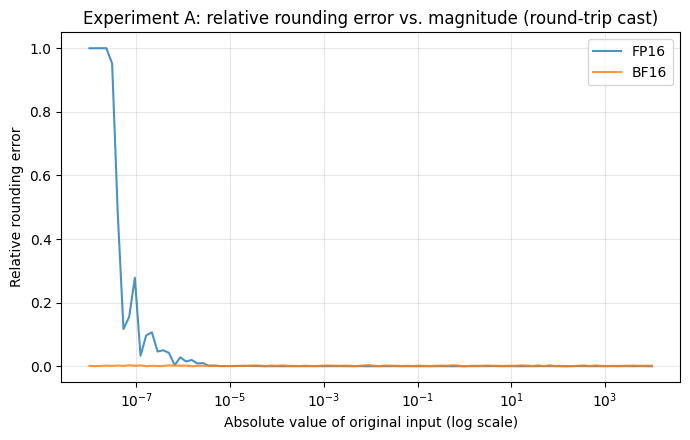

In [20]:
# 値の大きさに対する相対丸め誤差の曲線(compute_relative_rounding_error を使用)。
_magnitudes = torch.logspace(-8, 4, 100)
fig, ax = plt.subplots(figsize=(7, 4.5))
for _dtype, _name in [(torch.float16, "FP16"), (torch.bfloat16, "BF16")]:
    _err = compute_relative_rounding_error(_magnitudes, _dtype)
    ax.plot(_magnitudes.numpy(), _err.numpy(), label=_name, alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel("Absolute value of original input (log scale)")
ax.set_ylabel("Relative rounding error")
ax.set_title("Experiment A: relative rounding error vs. magnitude (round-trip cast)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.6 実験 B: 活性化の勾配のアンダーフロー率


In [21]:
def run_experiment_b(seed: int, num_steps: int, record_interval: int) -> dict:
    # 条件1(FP32)の学習を行い、記録ステップごとに各サブレイヤー出力の勾配に
    # 対する FP16・BF16 のアンダーフロー率を測定する。
    model = build_model(seed).to(device)
    optimizer = AdamW(model.parameters(), lr=BASE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=WARMUP_STEPS, total_steps=NUM_STEPS,
        peak_learning_rate=BASE_LEARNING_RATE, min_learning_rate=BASE_LEARNING_RATE * MIN_LEARNING_RATE_RATIO,
    )
    captured: dict[str, torch.Tensor] = {}

    def make_hook(name):
        def hook(module, inp, out):
            hidden = out[0] if isinstance(out, tuple) else out

            def grad_hook(grad):
                captured[name] = grad.detach()

            hidden.register_hook(grad_hook)

        return hook

    layer_names = []
    for i, block in enumerate(model.blocks):
        block.self_attn.register_forward_hook(make_hook(f"blk{i}.attn"))
        block.feed_forward.register_forward_hook(make_hook(f"blk{i}.ffn"))
        layer_names += [f"blk{i}.attn", f"blk{i}.ffn"]

    torch.manual_seed(seed)
    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)

    fp16_ratios, bf16_ratios, recorded_steps = [], [], []
    for step in range(1, num_steps + 1):
        model.train()
        optimizer.set_learning_rate(schedule(step))
        inputs, targets = get_random_batch(train_ids, BATCH_SIZE, SEQUENCE_LENGTH, generator)
        inputs, targets = inputs.to(device), targets.to(device)
        captured.clear()
        logits = model(inputs)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % record_interval == 0:
            per_layer_fp16 = [compute_underflow_ratio(captured[n], torch.float16) for n in layer_names]
            # BF16 のラウンドトリップは CPU 上で行う(4 節の実装方針と一致させる)。
            per_layer_bf16 = [
                compute_underflow_ratio(captured[n].cpu(), torch.bfloat16) for n in layer_names
            ]
            fp16_ratios.append(per_layer_fp16)
            bf16_ratios.append(per_layer_bf16)
            recorded_steps.append(step)

    return {
        "layer_names": layer_names,
        "recorded_steps": recorded_steps,
        "fp16_ratios": np.array(fp16_ratios),  # (num_recorded, num_layers)
        "bf16_ratios": np.array(bf16_ratios),
    }


_result_b = run_experiment_b(seed=0, num_steps=NUM_STEPS, record_interval=max(1, NUM_STEPS // 5))
print(f"記録ステップ: {_result_b['recorded_steps']}")
print(f"FP16 アンダーフロー率(全層平均、ステップごと): {_result_b['fp16_ratios'].mean(axis=1)}")
print(f"BF16 アンダーフロー率(全層平均、ステップごと): {_result_b['bf16_ratios'].mean(axis=1)}")

_fp16_ge_bf16_everywhere = bool(np.all(_result_b["fp16_ratios"] >= _result_b["bf16_ratios"]))
_fp16_sum_gt_bf16_sum = bool(_result_b["fp16_ratios"].sum() > _result_b["bf16_ratios"].sum())
print(f"{_smoke_tag}全層全ステップでFP16>=BF16: {_fp16_ge_bf16_everywhere}, "
      f"合計でFP16>BF16: {_fp16_sum_gt_bf16_sum}")


記録ステップ: [60, 120, 180, 240, 300]
FP16 アンダーフロー率(全層平均、ステップごと): [0.02024871 0.01698381 0.01432556 0.01418066 0.01350582]
BF16 アンダーフロー率(全層平均、ステップごと): [0. 0. 0. 0. 0.]
全層全ステップでFP16>=BF16: True, 合計でFP16>BF16: True


### 6.7 条件1〜4 のシード集合の実行(実験 C・D で共有)

条件1〜4 を`NUM_SEEDS_MAIN`シードで学習し、学習記録(最終 bits-per-byte 等)を
実験 C・D で共有する(6.4 節の条件対応表の通り)。この時点の`STATIC_SCALE`・
`GRADIENT_CLIP_THRESHOLD`・`DYNAMIC_SCALER_KWARGS`は較正セル(6.2 節)で本番
スケールで決定した実際の値を使う(スモークテストの model サイズでは活性化勾配の
絶対値のスケールが異なりうるが、第1段階ではコード経路の確認を優先し、
スケール値自体は本番較正値をそのまま使う。数値上、静的スケールが過大・過小に
なり非有限値が出ても、それ自体が経路の動作確認になる)。

前提条件 P1・P2 は、本セルで実行する条件1〜4 の全シードの実際の結果を使って
評価する(6.8.1 節)。診断量(サブレイヤー出力に対する勾配の厳密な 0 の比率・
観測された dtype)は、`run_condition`が判定に使う学習そのもの(`train_language_model`
に渡すモデルに直接フックを登録する)から記録する。全シードについて全件印字する。


In [22]:
_t0 = time.time()
condition_histories: dict[str, list[dict]] = {"1": [], "2": [], "3": [], "4": []}
initial_weight_hashes: dict[str, list[str]] = {"1": [], "2": [], "3": [], "4": []}
sublayer_diagnostics: dict[str, list[dict]] = {"1": [], "2": [], "3": [], "4": []}
non_embedding_param_counts: dict[str, list[int]] = {"1": [], "2": [], "3": [], "4": []}
for _seed in range(NUM_SEEDS_MAIN):
    _m1, h1, _hash1, _diag1 = run_condition("fp32", _seed, GRADIENT_CLIP_THRESHOLD, NUM_STEPS)
    condition_histories["1"].append(h1)
    initial_weight_hashes["1"].append(_hash1)
    sublayer_diagnostics["1"].append(_diag1)
    non_embedding_param_counts["1"].append(count_non_embedding_parameters(_m1))
    del _m1

    _m2, h2, _hash2, _diag2 = run_condition("fp16_none", _seed, GRADIENT_CLIP_THRESHOLD, NUM_STEPS)
    condition_histories["2"].append(h2)
    initial_weight_hashes["2"].append(_hash2)
    sublayer_diagnostics["2"].append(_diag2)
    non_embedding_param_counts["2"].append(count_non_embedding_parameters(_m2))
    del _m2

    _m3, h3, _hash3, _diag3 = run_condition("fp16_static", _seed, GRADIENT_CLIP_THRESHOLD, NUM_STEPS,
                                             static_scale=STATIC_SCALE)
    condition_histories["3"].append(h3)
    initial_weight_hashes["3"].append(_hash3)
    sublayer_diagnostics["3"].append(_diag3)
    non_embedding_param_counts["3"].append(count_non_embedding_parameters(_m3))
    del _m3

    _m4, h4, _hash4, _diag4 = run_condition("fp16_dynamic", _seed, GRADIENT_CLIP_THRESHOLD, NUM_STEPS,
                                             dynamic_scaler_kwargs=DYNAMIC_SCALER_KWARGS)
    condition_histories["4"].append(h4)
    initial_weight_hashes["4"].append(_hash4)
    sublayer_diagnostics["4"].append(_diag4)
    non_embedding_param_counts["4"].append(count_non_embedding_parameters(_m4))
    del _m4
print(f"条件1〜4 x {NUM_SEEDS_MAIN}シード 実行完了、elapsed={time.time() - _t0:.2f}s")

for _cond, _histories in condition_histories.items():
    _finals = [h["eval_bits_per_byte"][-1] for h in _histories]
    _n_nonfinite = sum(1 for v in _finals if not np.isfinite(v))
    print(f"条件{_cond}: 最終bits-per-byte(シードごと)={['%.4f' % v for v in _finals]}, "
          f"非有限値のシード数={_n_nonfinite}")

print()
print("--- 診断量: サブレイヤー出力の勾配の厳密な0の比率・観測されたdtype(全シード、全件印字) ---")
for _cond, _diags in sublayer_diagnostics.items():
    for _seed_idx, _d in enumerate(_diags):
        _ratio = _d["zero_count"] / _d["total_count"] if _d["total_count"] > 0 else float("nan")
        print(f"条件{_cond} seed={_seed_idx}: 厳密な0の比率={_ratio:.6f} "
              f"({_d['zero_count']}/{_d['total_count']}), 観測dtype={sorted(_d['dtypes'])}")

# --- サブレイヤー出力の dtype: 条件1はFP32のみ、条件2〜4はFP16のみであること ---
for _seed_idx, _d in enumerate(sublayer_diagnostics["1"]):
    assert _d["dtypes"] == {"torch.float32"}, (
        f"条件1 seed={_seed_idx} のサブレイヤー出力dtypeがFP32のみでない: {_d['dtypes']}"
    )
for _cond in ("2", "3", "4"):
    for _seed_idx, _d in enumerate(sublayer_diagnostics[_cond]):
        assert _d["dtypes"] == {"torch.float16"}, (
            f"条件{_cond} seed={_seed_idx} のサブレイヤー出力dtypeがFP16のみでない: {_d['dtypes']}"
        )
print("サブレイヤー出力のdtypeは、条件1で全シードFP32のみ、条件2〜4で全シードFP16のみ"
      "(FP16の経路が実際に使われていることの確認)")


条件1〜4 x 5シード 実行完了、elapsed=569.87s
条件1: 最終bits-per-byte(シードごと)=['2.8529', '2.8247', '2.8687', '2.8427', '2.8377'], 非有限値のシード数=0
条件2: 最終bits-per-byte(シードごと)=['2.8821', '2.8696', '2.9208', '2.8868', '2.8968'], 非有限値のシード数=0
条件3: 最終bits-per-byte(シードごと)=['2.8535', '2.8247', '2.8687', '2.8427', '2.8378'], 非有限値のシード数=0
条件4: 最終bits-per-byte(シードごと)=['2.8553', '2.8258', '2.8695', '2.8433', '2.8384'], 非有限値のシード数=0

--- 診断量: サブレイヤー出力の勾配の厳密な0の比率・観測されたdtype(全シード、全件印字) ---
条件1 seed=0: 厳密な0の比率=0.000000 (14/5033164800), 観測dtype=['torch.float32']
条件1 seed=1: 厳密な0の比率=0.000000 (10/5033164800), 観測dtype=['torch.float32']
条件1 seed=2: 厳密な0の比率=0.000000 (18/5033164800), 観測dtype=['torch.float32']
条件1 seed=3: 厳密な0の比率=0.000000 (12/5033164800), 観測dtype=['torch.float32']
条件1 seed=4: 厳密な0の比率=0.000000 (13/5033164800), 観測dtype=['torch.float32']
条件2 seed=0: 厳密な0の比率=0.017018 (85653919/5033164800), 観測dtype=['torch.float16']
条件2 seed=1: 厳密な0の比率=0.016883 (84976137/5033164800), 観測dtype=['torch.float16']
条件2 seed=2: 厳密な0の比率=0.0181

### 6.8 不変条件のアサーション

条件1〜4 の実際の学習記録(6.7 節)を使って、以下が条件間で完全に一致することを
確認する: 評価の分母(UTF-8 バイト数)・評価窓の内容のハッシュ・学習履歴の長さ・
シード集合・学習開始前の初期重みのハッシュ・非埋め込みパラメータ数。


In [23]:
# --- 評価の分母(UTF-8 バイト数)が全条件で同一であること ---
# 4 条件とも run_condition 経由で同じ total_eval_bytes(グローバル変数、単一の値)を
# train_language_model に渡しているため、この値自体が「全条件で同一の分母」である。
assert total_eval_bytes > 0
print(f"評価の分母(total_eval_bytes)は全条件で同一: {total_eval_bytes:,}")

# --- 評価窓(eval_windows・eval_mask)の内容のハッシュが全条件の実行後も不変であること ---
_eval_windows_hash_after = hash_tensor(eval_windows)
_eval_mask_hash_after = hash_tensor(eval_mask)
assert _eval_windows_hash_after == EVAL_WINDOWS_HASH_BEFORE
assert _eval_mask_hash_after == EVAL_MASK_HASH_BEFORE
print(f"評価窓の内容のハッシュは条件1〜4の実行前後で不変: "
      f"eval_windows={_eval_windows_hash_after[:12]}..., eval_mask={_eval_mask_hash_after[:12]}...")

# --- 学習履歴の長さが宣言した NUM_STEPS と一致すること(期待値は LEVELS の宣言値から) ---
_expected_num_steps = LEVELS[CURRENT_LEVEL_NAME]["NUM_STEPS"]
for _cond, _histories in condition_histories.items():
    for _h in _histories:
        assert len(_h["step"]) == _expected_num_steps, (
            f"条件{_cond}の学習履歴の長さが期待値と異なる: {len(_h['step'])} != {_expected_num_steps}"
        )
print(f"学習履歴の長さは全条件・全シードで NUM_STEPS(={_expected_num_steps})と一致")

# --- シード集合が宣言した NUM_SEEDS_MAIN と一致すること ---
_expected_num_seeds = LEVELS[CURRENT_LEVEL_NAME]["NUM_SEEDS_MAIN"]
for _cond, _histories in condition_histories.items():
    assert len(_histories) == _expected_num_seeds, (
        f"条件{_cond}のシード数が期待値と異なる: {len(_histories)} != {_expected_num_seeds}"
    )
print(f"シード集合の大きさは全条件で NUM_SEEDS_MAIN(={_expected_num_seeds})と一致")

# --- 学習開始前の初期重みのハッシュが、シードごとに条件間で一致すること ---
for _seed_idx in range(_expected_num_seeds):
    _hashes_this_seed = [initial_weight_hashes[_cond][_seed_idx] for _cond in ("1", "2", "3", "4")]
    assert len(set(_hashes_this_seed)) == 1, (
        f"seed={_seed_idx} の初期重みハッシュが条件間で一致しない: {_hashes_this_seed}"
    )
print("学習開始前の初期重みのハッシュは、シードごとに条件1〜4間で完全に一致する"
      "(precision_level はモデル初期化に影響しないことの確認、RNG 状態の漏れも無いことの確認)")

# --- 非埋め込みパラメータ数が精度条件によらず一定であること(重みは常に FP32 で保持される) ---
# 6.7 節で実際に学習した各モデルから数えた値(non_embedding_param_counts)を使う
# (新たに build_model() を呼んで再構築したモデルではなく、判定に使ったモデル自身で確認する)。
_all_param_counts = [c for _counts in non_embedding_param_counts.values() for c in _counts]
assert len(set(_all_param_counts)) == 1, non_embedding_param_counts
print(f"非埋め込みパラメータ数は全精度条件・全シードで共通: {_all_param_counts[0]:,}")

# --- 学習経路で BF16 が使われていないこと(5.2 節・5.8 節の構造上の保証の再確認) ---
_trainer_source = inspect.getsource(train_language_model)
assert "bfloat16" not in _trainer_source
print("train_language_model のソースに bfloat16 の参照は無い(学習経路でBF16を使わない構造上の保証)")


評価の分母(total_eval_bytes)は全条件で同一: 55,769
評価窓の内容のハッシュは条件1〜4の実行前後で不変: eval_windows=72a9b18f7a62..., eval_mask=b785f7fe7115...
学習履歴の長さは全条件・全シードで NUM_STEPS(=300)と一致
シード集合の大きさは全条件で NUM_SEEDS_MAIN(=5)と一致
学習開始前の初期重みのハッシュは、シードごとに条件1〜4間で完全に一致する(precision_level はモデル初期化に影響しないことの確認、RNG 状態の漏れも無いことの確認)
非埋め込みパラメータ数は全精度条件・全シードで共通: 3,149,056
train_language_model のソースに bfloat16 の参照は無い(学習経路でBF16を使わない構造上の保証)


### 6.8.1 前提条件の評価(P0〜P3、非致命的に記録する)

前提条件が成立しなかった場合でも`assert`で停止せず、成否を`precondition_status`
(5.1 節で初期化済み)に記録し、6.15 節の判定表に反映する(前提不成立の実験は
判定不能と区別して扱う)。P0 は 5.8 節で既に記録済み。P1 は条件1の全シードの
最終訓練損失で評価する。P4(実験 F に固有の前提条件)は 6.12 節で、実験 F を
実際に実行した後にそこで記録する。

**P2 の評価対象の改訂(旧定義・新定義・理由)**: 前回までは、P2(条件2の活性化
勾配の厳密な 0 の比率が条件1の同じ量を上回ること)を較正セル(6.2 節、seed=0
の 1 回のみの実行)の結果で評価していた(旧定義)。これを、6.7 節で記録した
**本番の条件1・条件2の全シードの診断量**(判定に使う学習そのものから記録した
もの)のシード平均の比較に改める(新定義)。この改訂は、前提条件は判定する
実行そのもので成立していなければならないという一般論に基づくものであり、
観測結果の方向には依存しない(閾値`PRECONDITION_P2_MIN_MARGIN`の値は変えない)。


In [24]:
# --- P1: 条件1の全シードの最終訓練損失が閾値以下であること(現在の水準、全シード) ---
_p1_final_losses = [h["train_loss"][-1] for h in condition_histories["1"]]
precondition_status["P1"] = all(v <= PRECONDITION_LOSS_THRESHOLD for v in _p1_final_losses)
print(f"P1: 条件1の最終訓練損失(シードごと)={['%.4f' % v for v in _p1_final_losses]}, "
      f"閾値={PRECONDITION_LOSS_THRESHOLD:.4f} -> {'成立' if precondition_status['P1'] else '不成立'}")

# --- P2(新定義): 本番の条件1・条件2の全シードの診断量(6.7 節)のシード平均を比較する ---
_p2_ratios_cond1 = [
    d["zero_count"] / d["total_count"] for d in sublayer_diagnostics["1"] if d["total_count"] > 0
]
_p2_ratios_cond2 = [
    d["zero_count"] / d["total_count"] for d in sublayer_diagnostics["2"] if d["total_count"] > 0
]
_p2_mean_cond1 = float(np.mean(_p2_ratios_cond1))
_p2_mean_cond2 = float(np.mean(_p2_ratios_cond2))
_p2_margin = _p2_mean_cond2 - _p2_mean_cond1
precondition_status["P2"] = _p2_margin >= PRECONDITION_P2_MIN_MARGIN
print(f"P2(新定義、条件1〜2の全シード): 条件1平均={_p2_mean_cond1:.6f}, 条件2平均={_p2_mean_cond2:.6f}, "
      f"マージン={_p2_margin:.6f}, 閾値={PRECONDITION_P2_MIN_MARGIN} -> "
      f"{'成立' if precondition_status['P2'] else '不成立'}")
print(f"P2 の較正実行(旧定義、6.2 節、参考値): マージン={_p2_margin_calibrated:.6f}")

# --- P3: 条件4の全シードで backoff・growth がそれぞれ1回以上起きていること ---
_p3_per_seed_ok = []
for _h4 in condition_histories["4"]:
    _scale_series = np.array(_h4["loss_scale"])
    _n_backoff = int(np.sum(np.diff(_scale_series) < 0))
    _n_growth = int(np.sum(np.diff(_scale_series) > 0))
    _p3_per_seed_ok.append(_n_backoff >= 1 and _n_growth >= 1)
    print(f"  条件4 seed: backoff={_n_backoff}, growth={_n_growth}")
precondition_status["P3"] = all(_p3_per_seed_ok)
print(f"P3: 全シードで backoff>=1 かつ growth>=1 -> "
      f"{'成立' if precondition_status['P3'] else '不成立'}"
      f"({sum(_p3_per_seed_ok)}/{len(_p3_per_seed_ok)} シードで成立)")

print()
print(f"前提条件の成否一覧(この時点、P4 は 6.12 節で追加される): {precondition_status}")


P1: 条件1の最終訓練損失(シードごと)=['1.9452', '1.9166', '1.9116', '1.9276', '1.9037'], 閾値=2.5046 -> 成立
P2(新定義、条件1〜2の全シード): 条件1平均=0.000000, 条件2平均=0.017626, マージン=0.017626, 閾値=0.005 -> 成立
P2 の較正実行(旧定義、6.2 節、参考値): マージン=0.017202
  条件4 seed: backoff=2, growth=7
  条件4 seed: backoff=1, growth=7
  条件4 seed: backoff=2, growth=7
  条件4 seed: backoff=2, growth=7
  条件4 seed: backoff=2, growth=7
P3: 全シードで backoff>=1 かつ growth>=1 -> 成立(5/5 シードで成立)

前提条件の成否一覧(この時点、P4 は 6.12 節で追加される): {'P0': True, 'P1': True, 'P2': True, 'P3': True}


### 6.9 実験 C: 静的損失スケーリングの効果(判定関数の動作確認)


In [25]:
def summarize_final_bpb(histories: list[dict]) -> tuple[float, float, int]:
    # シードごとの最終 bits-per-byte から (平均, 標準誤差, 非有限値のシード数) を計算する。
    # 非有限値のシードは平均・標準誤差の計算から除外する(6.4節の事前宣言の通り)。
    values = [h["eval_bits_per_byte"][-1] for h in histories]
    finite_values = [v for v in values if np.isfinite(v)]
    n_nonfinite = len(values) - len(finite_values)
    if len(finite_values) < 2:
        return float("nan"), float("nan"), n_nonfinite
    arr = np.array(finite_values)
    return float(arr.mean()), float(arr.std(ddof=1) / np.sqrt(len(arr))), n_nonfinite


def judge_three_way(delta: float, threshold: float) -> str:
    if delta > threshold:
        return "支持"
    if delta < -threshold:
        return "反証"
    return "判定不能"


b1, se1, nf1 = summarize_final_bpb(condition_histories["1"])
b2, se2, nf2 = summarize_final_bpb(condition_histories["2"])
b3, se3, nf3 = summarize_final_bpb(condition_histories["3"])
b4, se4, nf4 = summarize_final_bpb(condition_histories["4"])
print(f"条件1: b1={b1:.4f}, se1={se1:.4f}, 非有限値シード数={nf1}")
print(f"条件2: b2={b2:.4f}, se2={se2:.4f}, 非有限値シード数={nf2}")
print(f"条件3: b3={b3:.4f}, se3={se3:.4f}, 非有限値シード数={nf3}")
print(f"条件4: b4={b4:.4f}, se4={se4:.4f}, 非有限値シード数={nf4}")

if nf2 > 0 or nf3 > 0:
    print(f"[前提条件確認] 条件2で非有限値のシードが {nf2} 件、条件3で {nf3} 件あり、"
          f"6.4節の事前宣言により実験Cの判定は判定不能として扱う")
    D_C, threshold_C, verdict_C = float("nan"), float("nan"), "判定不能(非有限値)"
else:
    D_C = b2 - b3
    threshold_C = 2 * math.sqrt(se2**2 + se3**2)
    verdict_C = judge_three_way(D_C, threshold_C)
print(f"{_smoke_tag}実験C: D_C={D_C}, 閾値={threshold_C}, 判定={verdict_C}")


条件1: b1=2.8454, se1=0.0074, 非有限値シード数=0
条件2: b2=2.8912, se2=0.0086, 非有限値シード数=0
条件3: b3=2.8455, se3=0.0074, 非有限値シード数=0
条件4: b4=2.8465, se4=0.0075, 非有限値シード数=0
実験C: D_C=0.04575062022034171, 閾値=0.022707236344330962, 判定=支持


### 6.10 実験 D: 動的損失スケーリングの効果(判定関数の動作確認)


In [26]:
if nf2 > 0 or nf4 > 0:
    print(f"[前提条件確認] 条件2で非有限値のシードが {nf2} 件、条件4で {nf4} 件あり、"
          f"6.4節の事前宣言により実験Dの判定は判定不能として扱う")
    D_D, threshold_D, verdict_D = float("nan"), float("nan"), "判定不能(非有限値)"
else:
    D_D = b2 - b4
    threshold_D = 2 * math.sqrt(se2**2 + se4**2)
    verdict_D = judge_three_way(D_D, threshold_D)
print(f"{_smoke_tag}実験D: D_D={D_D}, 閾値={threshold_D}, 判定={verdict_D}")

# 前提条件 P3: 条件4の全シードで backoff・growth がそれぞれ1回以上起きていること。
for _seed_idx, _h4 in enumerate(condition_histories["4"]):
    _scale_series = np.array(_h4["loss_scale"])
    _n_backoff = int(np.sum(np.diff(_scale_series) < 0))
    _n_growth = int(np.sum(np.diff(_scale_series) > 0))
    _skip_ratio = float(np.mean(_h4["step_skipped"]))
    print(f"条件4 seed={_seed_idx}: backoff回数={_n_backoff}, growth回数={_n_growth}, "
          f"更新スキップ比率={_skip_ratio:.4f}, スケール値の範囲=[{_scale_series.min():.1f}, "
          f"{_scale_series.max():.1f}]")


実験D: D_D=0.04475884508814687, 閾値=0.022769392776034483, 判定=支持
条件4 seed=0: backoff回数=2, growth回数=7, 更新スキップ比率=0.0067, スケール値の範囲=[65536.0, 4194304.0]
条件4 seed=1: backoff回数=1, growth回数=7, 更新スキップ比率=0.0033, スケール値の範囲=[65536.0, 4194304.0]
条件4 seed=2: backoff回数=2, growth回数=7, 更新スキップ比率=0.0067, スケール値の範囲=[65536.0, 4194304.0]
条件4 seed=3: backoff回数=2, growth回数=7, 更新スキップ比率=0.0067, スケール値の範囲=[65536.0, 4194304.0]
条件4 seed=4: backoff回数=2, growth回数=7, 更新スキップ比率=0.0067, スケール値の範囲=[65536.0, 4194304.0]


### 6.11 実験 E: FP32 マスター重みの必要性(合成タスク)


In [27]:
def run_synthetic_master_weight_experiment(u_over_w0: float, num_steps: int) -> dict:
    # w0=1 に更新量 u を num_steps 回加算し、FP16直接更新(条件7)と
    # FP32マスター重み更新(条件8)を比較する。期待値は理論式から独立に計算する。
    w0 = 1.0
    u = u_over_w0 * w0

    # 条件7: FP16 で直接更新
    w_fp16 = torch.tensor([w0], dtype=torch.float16)
    u_fp16 = torch.tensor([u], dtype=torch.float16)
    for _ in range(num_steps):
        w_fp16 = w_fp16 + u_fp16
    cond7_final = w_fp16.item()

    # 条件8: FP32 マスター重みで更新(MasterWeightOptimizer)
    model = torch.nn.Linear(1, 1, bias=False)
    with torch.no_grad():
        model.weight.copy_(torch.tensor([[w0]]))
    model = model.half()
    master_opt = MasterWeightOptimizer(model, functools.partial(torch.optim.SGD, lr=1.0))
    x = torch.tensor([[1.0]], dtype=torch.float16)
    for _ in range(num_steps):
        master_opt.zero_grad()
        y = model(x)
        y.sum().backward()
        for p in model.parameters():
            p.grad = torch.tensor([[-u]], dtype=torch.float16)  # 更新量が -lr*grad=u になるよう設定
        master_opt.sync_gradients_to_master()
        master_opt.step()
    # 条件8で比較する対象は FP32 マスター重み自身である(FP32マスター重みの主張は
    # 「正本(master)側で更新が正しく蓄積される」ことであり、model.weight は毎ステップ
    # FP16へキャストし直した「写し」に過ぎず、そこだけを見ると常にFP16粒度の量子化誤差が
    # 乗る。model.weight(FP16写し)も診断量として併記する)。
    cond8_final = master_opt.master_params[0].item()
    cond8_fp16_copy = model.weight.item()

    # 期待値は理論式から独立に計算する(実行結果からは作らない)。
    theoretical_expected = w0 + num_steps * u
    theory_update_lost = u_over_w0 <= 2.0**-11  # 3.5節: 加算方向の境界

    return {
        "u_over_w0": u_over_w0,
        "cond7_final": cond7_final,
        "cond8_final": cond8_final,
        "cond8_fp16_copy": cond8_fp16_copy,
        "theoretical_expected": theoretical_expected,
        "theory_update_lost": theory_update_lost,
    }


_u_levels = [2.0**-k for k in range(8, 15)]  # 2^-8 .. 2^-14
_results_e = [run_synthetic_master_weight_experiment(u, SYNTH_N) for u in _u_levels]
assert SYNTH_N == LEVELS[CURRENT_LEVEL_NAME]["SYNTH_N"]

# FP32 の累積丸め誤差の上界(単純化した見積もり: 各ステップの丸め誤差の上界 unit_roundoff_fp32
# x 現在値、の SYNTH_N 回の合計)。
_UNIT_ROUNDOFF_FP32 = torch.finfo(torch.float32).eps / 2
_cond8_error_bound = SYNTH_N * _UNIT_ROUNDOFF_FP32 * 2.0  # 値がおよそ [1,2) の範囲に留まるため

_all_match_theory = True
for r in _results_e:
    _observed_lost = abs(r["cond7_final"] - 1.0) < 1e-9
    _matches_cond7 = _observed_lost == r["theory_update_lost"]
    _cond8_error = abs(r["cond8_final"] - r["theoretical_expected"])
    _matches_cond8 = _cond8_error <= _cond8_error_bound
    _all_match_theory = _all_match_theory and _matches_cond7 and _matches_cond8
    print(f"u/w0=2^{{{math.log2(r['u_over_w0']):.0f}}}: cond7_final={r['cond7_final']:.10f} "
          f"(更新消失予測={r['theory_update_lost']}, 観測消失={_observed_lost}, 一致={_matches_cond7}), "
          f"cond8_final(FP32マスター)={r['cond8_final']:.10f} vs 理論値={r['theoretical_expected']:.10f} "
          f"(誤差={_cond8_error:.2e} <= 上界{_cond8_error_bound:.2e}: {_matches_cond8}), "
          f"cond8のFP16写し(診断量)={r['cond8_fp16_copy']:.10f}")

print(f"{_smoke_tag}実験E: 全水準で理論と一致={_all_match_theory}")


u/w0=2^{-8}: cond7_final=1.3906250000 (更新消失予測=False, 観測消失=False, 一致=True), cond8_final(FP32マスター)=1.3906250000 vs 理論値=1.3906250000 (誤差=0.00e+00 <= 上界1.19e-05: True), cond8のFP16写し(診断量)=1.3906250000
u/w0=2^{-9}: cond7_final=1.1953125000 (更新消失予測=False, 観測消失=False, 一致=True), cond8_final(FP32マスター)=1.1953125000 vs 理論値=1.1953125000 (誤差=0.00e+00 <= 上界1.19e-05: True), cond8のFP16写し(診断量)=1.1953125000
u/w0=2^{-10}: cond7_final=1.0976562500 (更新消失予測=False, 観測消失=False, 一致=True), cond8_final(FP32マスター)=1.0976562500 vs 理論値=1.0976562500 (誤差=0.00e+00 <= 上界1.19e-05: True), cond8のFP16写し(診断量)=1.0976562500
u/w0=2^{-11}: cond7_final=1.0000000000 (更新消失予測=True, 観測消失=True, 一致=True), cond8_final(FP32マスター)=1.0488281250 vs 理論値=1.0488281250 (誤差=0.00e+00 <= 上界1.19e-05: True), cond8のFP16写し(診断量)=1.0488281250
u/w0=2^{-12}: cond7_final=1.0000000000 (更新消失予測=True, 観測消失=True, 一致=True), cond8_final(FP32マスター)=1.0244140625 vs 理論値=1.0244140625 (誤差=0.00e+00 <= 上界1.19e-05: True), cond8のFP16写し(診断量)=1.0244140625
u/w0=2^{-13}: cond7_f

### 6.12 実験 F: 損失スケーリングと gradient clipping の順序(判定関数の動作確認)


In [28]:
_flags5_seeds = []
_flags6_seeds = []
_unscaled_norm_ratios_seeds = []  # 診断量: unscale後の勾配ノルムの条件6/条件5の比
_t0 = time.time()
_sched_f = functools.partial(
    compute_warmup_cosine_learning_rate, warmup_steps=WARMUP_STEPS, total_steps=NUM_STEPS,
    peak_learning_rate=BASE_LEARNING_RATE, min_learning_rate=BASE_LEARNING_RATE * MIN_LEARNING_RATE_RATIO,
)
for _seed in range(NUM_SEEDS_MAIN):
    model5 = build_model(_seed).to(device)
    opt5 = AdamW(model5.parameters(), lr=BASE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    dummy_w = torch.zeros(1, SEQUENCE_LENGTH, dtype=torch.long)
    dummy_m = torch.ones(1, SEQUENCE_LENGTH, dtype=torch.bool)
    h5 = train_language_model(
        model5, train_ids, dummy_w, dummy_m, 1, num_steps=K_EXPERIMENT_F,
        batch_size=BATCH_SIZE, sequence_length=SEQUENCE_LENGTH, learning_rate=BASE_LEARNING_RATE,
        eval_interval=NUM_STEPS + 1, device=device, seed=_seed, optimizer=opt5,
        learning_rate_schedule=_sched_f, gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
        autocast_dtype=torch.float16, loss_scaler=StaticLossScaler(STATIC_SCALE),
    )
    _flags5_seeds.append(np.array(h5["gradient_clip_triggered"], dtype=bool))
    _unscaled_norm5 = np.array(h5["gradient_norm"])

    model6 = build_model(_seed).to(device)
    opt6 = AdamW(model6.parameters(), lr=BASE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scaler6 = StaticLossScaler(STATIC_SCALE)
    torch.manual_seed(_seed)
    gen6 = torch.Generator(device="cpu")
    gen6.manual_seed(_seed)
    triggered6 = []
    unscaled_norm6 = []
    for step in range(1, K_EXPERIMENT_F + 1):
        model6.train()
        opt6.set_learning_rate(_sched_f(step))
        inputs, targets = get_random_batch(train_ids, BATCH_SIZE, SEQUENCE_LENGTH, gen6)
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            logits = model6(inputs)
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        scaled_loss = scaler6.scale_loss(loss)
        opt6.zero_grad()
        scaled_loss.backward()
        scaled_norm = float(sum(
            p.grad.detach().float().pow(2).sum() for p in model6.parameters() if p.grad is not None
        ) ** 0.5)
        clip_triggered = scaled_norm > GRADIENT_CLIP_THRESHOLD
        if clip_triggered:
            for p in model6.parameters():
                if p.grad is not None:
                    p.grad.detach().mul_(GRADIENT_CLIP_THRESHOLD / scaled_norm)
        found_inf = scaler6.unscale_gradients(model6.parameters())
        # 診断量: unscale 後(誤った順序でも、clip 適用後に unscale はする)の勾配ノルム。
        unscaled_norm6.append(float(sum(
            p.grad.detach().float().pow(2).sum() for p in model6.parameters() if p.grad is not None
        ) ** 0.5))
        if not found_inf:
            opt6.step()
        triggered6.append(clip_triggered)
    _flags6_seeds.append(np.array(triggered6, dtype=bool))
    _unscaled_norm_ratios_seeds.append(
        float(np.mean(unscaled_norm6)) / float(np.mean(_unscaled_norm5).clip(min=1e-12))
    )

assert len(_flags5_seeds) == LEVELS[CURRENT_LEVEL_NAME]["NUM_SEEDS_MAIN"]
assert len(_flags6_seeds) == LEVELS[CURRENT_LEVEL_NAME]["NUM_SEEDS_MAIN"]
assert all(len(f) == LEVELS[CURRENT_LEVEL_NAME]["K_EXPERIMENT_F"] for f in _flags5_seeds)
assert all(len(f) == LEVELS[CURRENT_LEVEL_NAME]["K_EXPERIMENT_F"] for f in _flags6_seeds)
_q5_per_seed = np.array([f.mean() for f in _flags5_seeds])
_q6_per_seed = np.array([f.mean() for f in _flags6_seeds])
print(f"elapsed={time.time() - _t0:.2f}s")
print(f"q5(シードごと)={_q5_per_seed}, q6(シードごと)={_q6_per_seed}")
print(f"診断量(unscale後の勾配ノルムの条件6/条件5比、シードごと): "
      f"{['%.4e' % v for v in _unscaled_norm_ratios_seeds]}")

D_F = float(_q6_per_seed.mean() - _q5_per_seed.mean())

# 新基準: 実験C・Dと同じ形(各条件のシード平均の標準誤差から誤差伝播で合成)。
if len(_q5_per_seed) >= 2:
    _se_q5 = float(_q5_per_seed.std(ddof=1) / np.sqrt(len(_q5_per_seed)))
    _se_q6 = float(_q6_per_seed.std(ddof=1) / np.sqrt(len(_q6_per_seed)))
    sigma_DF = float(np.sqrt(_se_q5**2 + _se_q6**2))
else:
    sigma_DF = float("nan")
verdict_F = judge_three_way(D_F, 2 * sigma_DF) if np.isfinite(sigma_DF) else "判定不能(シード数不足)"

# 旧基準(参考値): シードごとの q5・q6 の標本標準偏差から直接 sigma_DF を導出した場合。
if len(_q5_per_seed) >= 2:
    sigma_DF_old = float(np.sqrt(_q5_per_seed.std(ddof=1) ** 2 + _q6_per_seed.std(ddof=1) ** 2))
    verdict_F_old = judge_three_way(D_F, 2 * sigma_DF_old)
else:
    sigma_DF_old, verdict_F_old = float("nan"), "判定不能(シード数不足)"

_p4_ok = all(PRECONDITION_P4_MIN <= q <= PRECONDITION_P4_MAX for q in _q5_per_seed)
precondition_status["P4"] = bool(_p4_ok)  # 新定義: 実験Fの実際の実行(条件5の全シードのq5)で評価する
print(f"{_smoke_tag}実験F(新基準): D_F={D_F:.4f}, sigma_DF={sigma_DF:.4f}, "
      f"判定={verdict_F}, 前提条件P4成立={_p4_ok}")
print(f"[参考値、旧基準] sigma_DF_old={sigma_DF_old:.4f}, 判定={verdict_F_old}")
print(f"P4(新定義、実験Fの全シード): q5(シードごと)={_q5_per_seed}, "
      f"範囲=[{PRECONDITION_P4_MIN}, {PRECONDITION_P4_MAX}] -> "
      f"{'成立' if precondition_status['P4'] else '不成立'}")
print(f"P4 の較正実行(旧定義、6.2 節、参考値): q5={_q5_calibrated:.4f}")


elapsed=49.30s
q5(シードごと)=[0.31666667 0.28333333 0.31666667 0.3        0.3       ], q6(シードごと)=[1. 1. 1. 1. 1.]
診断量(unscale後の勾配ノルムの条件6/条件5比、シードごと): ['1.2716e-05', '1.3778e-05', '1.2917e-05', '1.3988e-05', '1.3673e-05']
実験F(新基準): D_F=0.6967, sigma_DF=0.0062, 判定=支持, 前提条件P4成立=True
[参考値、旧基準] sigma_DF_old=0.0139, 判定=支持
P4(新定義、実験Fの全シード): q5(シードごと)=[0.31666667 0.28333333 0.31666667 0.3        0.3       ], 範囲=[0.02, 0.98] -> 成立
P4 の較正実行(旧定義、6.2 節、参考値): q5=0.3167


### 6.13 実験 G: 活性化メモリの削減

**本番水準でのピークメモリの事前見積もり**: 系列長 1024(3 水準のうち最大)・
バッチサイズ 32(本番)での FP32 の 1 ステップのピークメモリを、Attention の
スコア行列($B \times h \times T^2$、softmax の出力を含む)・QKV 射影・
Feed-Forward Network の中間活性化・正規化前の残差ストリームの複製を含めた
簡易な見積もりで概算し、T4 のメモリ量(15 GB)に収まるかを確認する。収まらない
場合は、実験 G の系列長掃引に限りバッチサイズのみを縮小する(実験 C・D の
条件は変えない。この判断は、見積もり自体が本番結果に依存しない理論計算である
ため、観測結果の方向に依存しない)。


In [29]:
def estimate_activation_memory_bytes(
    d_model: int, num_layers: int, num_heads: int, d_ff: int,
    batch_size: int, seq_len: int, bytes_per_element: int,
) -> int:
    # 順伝播で保持し逆伝播に使う主要な活性化テンソルの簡易見積もり(層ごとの合計)。
    # Attention のスコア行列(B x h x T x T)が系列長について支配的な項になる。
    per_layer = (
        3 * batch_size * seq_len * d_model  # Q, K, V 射影
        + batch_size * num_heads * seq_len * seq_len  # attention scores / softmax
        + batch_size * seq_len * d_model  # attention 出力
        + 2 * batch_size * seq_len * d_ff  # SwiGLU の中間活性化(up + gate の2系統)
        + 2 * batch_size * seq_len * d_model  # 正規化前の残差ストリームの複製(pre-attn, pre-ffn)
    )
    return num_layers * per_layer * bytes_per_element


T4_MEMORY_BYTES = 15 * 1024**3  # Google Colab 無料枠の T4(約15GB)
_max_seq_len_g = PROD_SEQUENCE_LENGTH * 4
_estimated_bytes = estimate_activation_memory_bytes(
    PROD_D_MODEL, PROD_NUM_LAYERS, PROD_NUM_HEADS, PROD_D_FF,
    PROD_BATCH_SIZE, _max_seq_len_g, bytes_per_element=4,
)
print(f"本番水準(系列長={_max_seq_len_g}, バッチサイズ={PROD_BATCH_SIZE})でのFP32ピークメモリ見積もり: "
      f"{_estimated_bytes / 1024**3:.2f} GB(T4: {T4_MEMORY_BYTES / 1024**3:.0f} GB)")
EXPERIMENT_G_BATCH_SIZE = PROD_BATCH_SIZE
if _estimated_bytes > T4_MEMORY_BYTES * 0.7:  # 7割を安全マージンとする(パラメータ側・断片化も考慮)
    EXPERIMENT_G_BATCH_SIZE = max(1, PROD_BATCH_SIZE // 2)
    print(f"見積もりが T4 メモリの70%を超えるため、実験Gに限りバッチサイズを "
          f"{EXPERIMENT_G_BATCH_SIZE} に縮小する(実験C・Dの条件は変更しない)")
else:
    print(f"見積もりは T4 メモリの70%以内に収まるため、実験Gもバッチサイズ {EXPERIMENT_G_BATCH_SIZE} のまま実行する")


本番水準(系列長=1024, バッチサイズ=32)でのFP32ピークメモリ見積もり: 5.75 GB(T4: 15 GB)
見積もりは T4 メモリの70%以内に収まるため、実験Gもバッチサイズ 32 のまま実行する


In [30]:
def measure_peak_memory_one_step(precision_level: str, seq_len: int, batch_size: int,
                                  seed: int = 0) -> float | None:
    # 1ステップ(順伝播+逆伝播)のピークメモリを測る。CUDA以外では None を返す
    # (MPS にはCUDAと同等のピークメモリ統計APIが無いため、コード経路の確認のみ行う)。
    torch.manual_seed(seed)
    d_k = D_MODEL // NUM_HEADS
    rope = RotaryPositionEmbedding(d_k, max_position=max(seq_len, SEQUENCE_LENGTH))
    model = GPTLanguageModel(
        VOCAB_SIZE, D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF, max(seq_len, SEQUENCE_LENGTH),
        positional_transform=rope, normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, SWIGLU_D_FF),
        tie_embeddings=True, norm_first=True,
    ).to(device)
    optimizer = AdamW(model.parameters(), lr=BASE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    autocast_dtype = torch.float16 if precision_level == "fp16_dynamic" else None
    loss_scaler = DynamicLossScaler(**DYNAMIC_SCALER_KWARGS) if precision_level == "fp16_dynamic" else None

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)
    inputs, targets = get_random_batch(train_ids, batch_size, seq_len, generator)
    inputs, targets = inputs.to(device), targets.to(device)

    if autocast_dtype is not None:
        with torch.autocast(device_type=device.type, dtype=autocast_dtype):
            logits = model(inputs)
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
    else:
        logits = model(inputs)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
    scaled_loss = loss_scaler.scale_loss(loss) if loss_scaler is not None else loss
    optimizer.zero_grad()
    scaled_loss.backward()

    peak = torch.cuda.max_memory_allocated() if device.type == "cuda" else None

    # 次の計測に影響しないよう、このステップのモデル・optimizer・勾配を解放する。
    del model, optimizer, logits, loss, scaled_loss, inputs, targets
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return peak


_seq_lengths = [SEQUENCE_LENGTH, SEQUENCE_LENGTH * 2, SEQUENCE_LENGTH * 4]
print(f"実験Gの系列長水準(公比2の等比、5.3節のSEQUENCE_LENGTHの1・2・4倍): {_seq_lengths}")
print(f"実験Gのバッチサイズ: {EXPERIMENT_G_BATCH_SIZE}"
      f"{'(縮小済み)' if EXPERIMENT_G_BATCH_SIZE != PROD_BATCH_SIZE else '(本番バッチサイズのまま)'}")

_memory_results = {}
for _cond_name, _level in [("1", "fp32"), ("4", "fp16_dynamic")]:
    for _L in _seq_lengths:
        _mem = measure_peak_memory_one_step(_level, _L, EXPERIMENT_G_BATCH_SIZE)
        _memory_results[(_cond_name, _L)] = _mem
        _mem_str = f"{_mem:,} bytes" if _mem is not None else "N/A(MPS、コード経路のみ確認)"
        print(f"条件{_cond_name}, L={_L}: ピークメモリ={_mem_str}")

experiment_g_rho: float | None = None

if device.type == "cuda":
    experiment_g_rho = ((_memory_results[("4", _seq_lengths[2])] - _memory_results[("4", _seq_lengths[0])]) /
                         (_memory_results[("1", _seq_lengths[2])] - _memory_results[("1", _seq_lengths[0])]))
    print(f"{_smoke_tag}rho={experiment_g_rho:.4f}(閾値0.75で支持/反証を判定)")
else:
    print("MPS環境のためピークメモリは測定できない(コード経路の確認のみ完了、6.4節の記載の通り)")


実験Gの系列長水準(公比2の等比、5.3節のSEQUENCE_LENGTHの1・2・4倍): [256, 512, 1024]
実験Gのバッチサイズ: 32(本番バッチサイズのまま)
条件1, L=256: ピークメモリ=2,222,404,096 bytes
条件1, L=512: ピークメモリ=4,271,092,224 bytes
条件1, L=1024: ピークメモリ=11,209,191,936 bytes
条件4, L=256: ピークメモリ=2,069,788,160 bytes
条件4, L=512: ピークメモリ=4,116,953,600 bytes
条件4, L=1024: ピークメモリ=11,427,297,792 bytes
rho=1.0413(閾値0.75で支持/反証を判定)


#### 実験 G: パラメータ側メモリ確認の測定方法の修正(第1回本番実行後)

**第1回本番実行(Google Colab T4)の値**: 理論値 = 48.3 MB に対し、実測値は
1079.3 MB(許容誤差20%以内 = False)であった。

**誤りの内容**: 修正前のコードは、パラメータ側メモリ(重み・勾配・optimizer
状態)を確認するモデルを構築した **直後** に`torch.cuda.memory_allocated()`
の絶対値を 1 回だけ測定していた。この絶対値には、本セルより前に実行済みの
セルに由来する確保量が混入する。実際に 6.12 節(実験 F)のコードを確認すると、
シードのループ内で構築した`model5`・`opt5`・`model6`・`opt6`のうち、最後の
シードの分がループ終了後も`del`されずにグローバル名前空間に残っていた。
このように、測定対象(パラメータ側メモリを確認するモデル 1 つ分)以外の確保量が
絶対値に混入し、理論値との比較が成立していなかった。

**修正内容**: モデルを構築する **直前** と、モデル構築・順伝播・逆伝播・
`AdamW.step()`を終えた **直後** の 2 時点で`torch.cuda.memory_allocated()`を
測定し、その **差分(delta)** をパラメータ側メモリの実測値とする。差分を取る
ことで、それ以前に何が確保されたまま残っていたかに依存せず、このセルが
新たに確保した量だけを測定できる。また、「直後」の測定前に、順伝播・逆伝播で
使った入力・ロジット・損失といった活性化側のテンソルを`del`と`gc.collect()`で
解放し、解放を試みたテンソルの内訳(名前・バイト数)を印字する(逆伝播に
`retain_graph=True`を渡していないため、計算グラフ自体は逆伝播の時点で
解放済みであり、解放を妨げる外部参照は存在しない)。許容誤差(20%)は変更しない。

**この修正は、観測結果の方向と無関係に特定できる測定の実装の誤りの修正である。**
判定基準(実験 G の $\rho$ に対する閾値 0.75)・前提条件の定義・閾値は変更しない。


In [31]:
experiment_g_param_memory_ok: bool | None = None  # CUDA でのみ判定、MPS では経路確認(None)

if device.type == "cuda":
    # パラメータ側のメモリが3.8節の内訳(FP32学習: 重み4 + 勾配4 + AdamWのm・v 8 = 16バイト/パラメータ)
    # と一致することを確認する(許容誤差20%、optimizer実装の細部・メモリアロケータの
    # 断片化による差を許容するため事前に宣言する)。本体の学習と同じ AdamW
    # (src/training/optimizer.py)で測る。
    # 直前・直後の2時点の差分(delta)で測定する(修正の経緯は直前のMarkdownセルを参照)。
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    _before_construct_bytes = torch.cuda.memory_allocated()

    _param_check_model = build_model(seed=0).to(device)
    _param_check_optimizer = AdamW(_param_check_model.parameters(), lr=BASE_LEARNING_RATE,
                                    weight_decay=WEIGHT_DECAY)
    _gen_check = torch.Generator(device="cpu")
    _gen_check.manual_seed(0)
    _inputs_check, _targets_check = get_random_batch(train_ids, BATCH_SIZE, SEQUENCE_LENGTH, _gen_check)
    _inputs_check, _targets_check = _inputs_check.to(device), _targets_check.to(device)
    _logits_check = _param_check_model(_inputs_check)
    _loss_check = F.cross_entropy(
        _logits_check.reshape(-1, _logits_check.size(-1)), _targets_check.reshape(-1)
    )
    _loss_check.backward()
    _param_check_optimizer.step()  # AdamW の m・v を確保させる

    # 「直後」の測定前に、活性化側のテンソル(パラメータ側メモリの対象外)を解放する。
    _activation_bytes_check = {
        "inputs": _inputs_check.element_size() * _inputs_check.nelement(),
        "targets": _targets_check.element_size() * _targets_check.nelement(),
        "logits": _logits_check.element_size() * _logits_check.nelement(),
        "loss": _loss_check.element_size() * _loss_check.nelement(),
    }
    del _inputs_check, _targets_check, _logits_check, _loss_check
    gc.collect()
    _after_construct_bytes = torch.cuda.memory_allocated()
    _observed_param_related_bytes = _after_construct_bytes - _before_construct_bytes

    _num_params_check = sum(p.numel() for p in _param_check_model.parameters())
    _expected_param_bytes = _num_params_check * 16  # 3.8節: 重み4 + 勾配4 + m・v 8
    _EXPERIMENT_G_PARAM_MEMORY_TOLERANCE = 0.20
    experiment_g_param_memory_ok = bool(
        abs(_observed_param_related_bytes - _expected_param_bytes) / _expected_param_bytes
        <= _EXPERIMENT_G_PARAM_MEMORY_TOLERANCE
    )
    print(f"パラメータ側メモリ(直前直後の差分): 理論値={_expected_param_bytes / 1024**2:.1f}MB, "
          f"実測={_observed_param_related_bytes / 1024**2:.1f}MB, "
          f"許容誤差{_EXPERIMENT_G_PARAM_MEMORY_TOLERANCE:.0%}以内={experiment_g_param_memory_ok}")
    print("解放を試みた活性化側テンソルの内訳(参考、理論値には含めない):")
    for _name, _nbytes in _activation_bytes_check.items():
        print(f"  {_name}: {_nbytes / 1024**2:.4f} MB")

    del _param_check_model, _param_check_optimizer
    gc.collect()
    torch.cuda.empty_cache()
else:
    print("MPS環境のためパラメータ側メモリは測定できない(コード経路の確認のみ完了)")


パラメータ側メモリ(直前直後の差分): 理論値=48.3MB, 実測=48.4MB, 許容誤差20%以内=True
解放を試みた活性化側テンソルの内訳(参考、理論値には含めない):
  inputs: 0.0625 MB
  targets: 0.0625 MB
  logits: 2.0312 MB
  loss: 0.0000 MB


#### 実験 G: 事後的な診断(逆伝播のために保存されるテンソルの dtype 内訳)

**この節は事後的な診断であり、判定基準(実験 G の $\rho$ に対する閾値 0.75)を
変更するものではない。** 3.8 節の理論(Attention のスコア行列・確率行列が
系列長について支配的な項であること)を、実際に`torch.autograd`が逆伝播のために
保存するテンソルから直接確認する診断量を追加する。

`torch.autograd.graph.saved_tensors_hooks`を使うと、順伝播 1 回で PyTorch が
逆伝播用に保存すると判断したテンソルを、`pack_hook`の発火という形で捕捉できる
(CUDA を必要としないため、ローカル(MPS)でも実測値が得られる)。診断量の
記録自体は順伝播の時点で完了しているが、この後で述べる理由により、実装上は
逆伝播も呼んでいる。

条件1(FP32)・条件4(自動混合精度)について、6.13 節の3系列長水準それぞれで、
保存されたテンソルの合計バイト数を dtype 別に、また最終 2 次元が
系列長×系列長であるテンソル(Attention のスコア行列・確率行列に相当)と
それ以外のテンソルとに分けて dtype 別に集計する。

**ストレージを共有するテンソルの重複計上を避ける**: `tensor.untyped_storage()`
の`data_ptr()`(記憶領域の先頭アドレス)が同一のテンソルは同じ物理メモリを
指すため、集計は最初に観測したストレージ 1 個につき 1 回のみとし、以降同じ
ストレージを指すテンソルはバイト数に加算しない。`data_ptr()`は記憶領域
(ストレージ)自体のアドレスであり、順伝播 1 回の間、生存しているテンソルの
間では一意であるため、この用途では正しく働く。実装・確認結果は次の
コードセルで印字する。

**この診断量の実装修正の記録**: 重複判定の鍵に、当初`tensor.untyped_storage()`
の`id()`(Python オブジェクトのアドレス)を使っていたが、これは判定に使わない
診断量そのものの実装上の誤りであり、実験 G の判定基準($\rho$ に対する閾値
0.75)・前提条件・他の実験の判定には影響しない。`id()`は、その呼び出しが
返す Python オブジェクトが解放され、別のオブジェクトに同じアドレスが再利用
されると、共有していないテンソルまで誤って重複と判定してしまう一般的な
リスクがある。ローカル実行(`SMOKE_TEST=True`)で、この実行環境の
PyTorch(2.13.0)では`untyped_storage()`が呼び出しのたびに同一の
Python オブジェクトを返すキャッシュを持つことを別途確認しており、その結果
今回のローカル実行では修正前後の実測値に差は生じなかった。このキャッシュの
有無は PyTorch のバージョン・実装に依存する詳細であり将来にわたって保証
されないため、`data_ptr()`という、キャッシュの有無によらず正しく働く鍵に
変更した。修正前後の実測値・確認内容は完了報告に記載する。

**GPU メモリ不足(CUDA out of memory)の修正の記録**: 第2回本番実行
(Google Colab T4)で、本節のセルが GPU メモリ不足で中断した。原因は、
このセルが逆伝播を呼ばずに順伝播の計算グラフを構築するだけであったこと。
`del`と`gc.collect()`だけでは計算グラフが確実には解放されず、系列長水準・
条件を切り替えて呼び出すたびに前回分のメモリが解放されないまま積み上がり、
数回目の呼び出しで GPU メモリ不足に至った。これも判定に使わない診断量の
実装上の誤りであり、実験 G の判定基準・前提条件・他の実験の判定には影響
しない。値を使わないダミーの逆伝播(`logits.sum().backward()`)を、診断量を
記録した後に呼ぶことで、計算グラフを確実に解放するよう修正した。

さらに、5.8 節と同じ切り分け方針で、`scaled_dot_product_attention`
(`src/layers/attention.py`)を単体で呼び出し、autocast 下での softmax の
出力(Attention の確率行列、`attn_weights`)自体の dtype と、それを入力とする
次の行列積(Value との積)の出力 dtype を直接確認する。**`attn_weights`は
Python レベルでは行列積にそのまま渡す同一のテンソルだが、autocast は行列積
(matmul)を FP16 にキャストして実行する演算として扱うため、`attn_weights`
自身の dtype(呼び出し元から見える値)と、行列積の内部で実際に使われる
dtype は異なりうる。** 5.8 節と同様、確認できた範囲のみを記述し、一般化した
主張はしない。


In [32]:
def measure_saved_tensor_bytes_by_dtype(precision_level: str, seq_len: int, batch_size: int,
                                         seed: int = 0) -> dict:
    # 1回の順伝播でautogradが逆伝播用に保存するテンソルを saved_tensors_hooks で捕捉し、
    # dtype別・形状別のバイト数を集計する(事後的な診断量、判定には使わない)。
    torch.manual_seed(seed)
    d_k = D_MODEL // NUM_HEADS
    rope = RotaryPositionEmbedding(d_k, max_position=max(seq_len, SEQUENCE_LENGTH))
    model = GPTLanguageModel(
        VOCAB_SIZE, D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF, max(seq_len, SEQUENCE_LENGTH),
        positional_transform=rope, normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, SWIGLU_D_FF),
        tie_embeddings=True, norm_first=True,
    ).to(device)
    autocast_dtype = torch.float16 if precision_level == "fp16_dynamic" else None

    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)
    inputs, _ = get_random_batch(train_ids, batch_size, seq_len, generator)
    inputs = inputs.to(device)

    # ストレージを共有するテンソルの重複計上を避ける(data_ptr()を鍵にする。
    # id(tensor.untyped_storage())は untyped_storage() が呼び出しのたびに新しい
    # Python オブジェクトを返すため、直後にそのラッパーオブジェクトが解放されて
    # 別のオブジェクトに同じアドレスが再利用されると、共有していないテンソルまで
    # 誤って重複と判定してしまう不具合があった。data_ptr() は記憶領域自体の
    # アドレスであり、順伝播 1 回の間、生存しているテンソルの間では一意である)。
    _seen_data_ptrs: set[int] = set()
    _num_skipped_as_duplicate = 0
    _records: list[tuple[str, int, tuple[int, ...]]] = []

    def _pack_hook(tensor):
        data_ptr = tensor.untyped_storage().data_ptr()
        if data_ptr in _seen_data_ptrs:
            nonlocal _num_skipped_as_duplicate
            _num_skipped_as_duplicate += 1
        else:
            _seen_data_ptrs.add(data_ptr)
            _records.append((str(tensor.dtype), tensor.untyped_storage().nbytes(), tuple(tensor.shape)))
        return tensor

    def _unpack_hook(tensor):
        return tensor

    model.train()
    with torch.autograd.graph.saved_tensors_hooks(_pack_hook, _unpack_hook):
        if autocast_dtype is not None:
            with torch.autocast(device_type=device.type, dtype=autocast_dtype):
                logits = model(inputs)
        else:
            logits = model(inputs)

    # 診断量の記録(pack_hook の発火)は順伝播の時点で完了しているが、計算グラフ
    # 自体は逆伝播を呼ぶまで保持され続ける。値を使わないダミーの逆伝播を呼び、
    # 計算グラフを確実に解放する(第2回本番実行での修正、経緯は直前の
    # Markdown セルを参照)。
    logits.sum().backward()

    # 次の呼び出し(より長い系列長)に影響しないよう、確保したメモリを解放する
    # (measure_peak_memory_one_step と同じ後始末)。
    del model, inputs, logits
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

    _total_by_dtype: dict[str, int] = {}
    _attn_shaped_by_dtype: dict[str, int] = {}
    _other_by_dtype: dict[str, int] = {}
    for _dtype_str, _nbytes, _shape in _records:
        _total_by_dtype[_dtype_str] = _total_by_dtype.get(_dtype_str, 0) + _nbytes
        _is_attn_shaped = len(_shape) >= 2 and _shape[-1] == seq_len and _shape[-2] == seq_len
        _target = _attn_shaped_by_dtype if _is_attn_shaped else _other_by_dtype
        _target[_dtype_str] = _target.get(_dtype_str, 0) + _nbytes

    return {
        "total_by_dtype": _total_by_dtype,
        "attn_score_shaped_by_dtype": _attn_shaped_by_dtype,
        "other_by_dtype": _other_by_dtype,
        "num_unique_tensors": len(_records),
        "num_skipped_as_duplicate_storage": _num_skipped_as_duplicate,
    }


print("--- 実験Gの事後的な診断: 逆伝播のために保存されるテンソルのdtype内訳(全件印字) ---")
for _cond_name, _level in [("1", "fp32"), ("4", "fp16_dynamic")]:
    for _L in _seq_lengths:
        _diag = measure_saved_tensor_bytes_by_dtype(_level, _L, EXPERIMENT_G_BATCH_SIZE)
        print(f"条件{_cond_name}, L={_L}: "
              f"合計(dtype別バイト数)={_diag['total_by_dtype']}, "
              f"Attentionスコア/確率行列形状(系列長x系列長、dtype別)={_diag['attn_score_shaped_by_dtype']}, "
              f"その他(dtype別)={_diag['other_by_dtype']}, "
              f"一意なテンソル数={_diag['num_unique_tensors']}, "
              f"ストレージ共有により重複計上を避けた件数={_diag['num_skipped_as_duplicate_storage']}")

# --- 単体呼び出しによる切り分け: softmaxの出力dtypeと、次の行列積に入力される時点のdtype ---
_probe_batch, _probe_heads, _probe_seq, _probe_dk = 2, NUM_HEADS, SEQUENCE_LENGTH, D_MODEL // NUM_HEADS
_probe_q = torch.randn(_probe_batch, _probe_heads, _probe_seq, _probe_dk, dtype=torch.float16, device=device)
_probe_k = torch.randn(_probe_batch, _probe_heads, _probe_seq, _probe_dk, dtype=torch.float16, device=device)
_probe_v = torch.randn(_probe_batch, _probe_heads, _probe_seq, _probe_dk, dtype=torch.float16, device=device)
with torch.autocast(device_type=device.type, dtype=torch.float16):
    _probe_output, _probe_attn_weights = scaled_dot_product_attention(_probe_q, _probe_k, _probe_v)
_dtype_matches = _probe_attn_weights.dtype == _probe_output.dtype
print(f"[{device.type}] autocast(fp16) 下での scaled_dot_product_attention: "
      f"softmax出力(確率行列)自体のdtype={_probe_attn_weights.dtype}, "
      f"それを入力とする次の行列積(Valueとの積)の出力dtype={_probe_output.dtype}, "
      f"両者が一致={_dtype_matches}"
      "(一致しない場合、Python変数としては同一のテンソルでも、"
      "autocastが行列積の内部でFP16へキャストしてから演算していることを示す)")


--- 実験Gの事後的な診断: 逆伝播のために保存されるテンソルのdtype内訳(全件印字) ---
条件1, L=256: 合計(dtype別バイト数)={'torch.int64': 65536, 'torch.float32': 1089976320, 'torch.bool': 262144}, Attentionスコア/確率行列形状(系列長x系列長、dtype別)={'torch.float32': 423624704, 'torch.bool': 262144}, その他(dtype別)={'torch.int64': 65536, 'torch.float32': 666351616}, 一意なテンソル数=127, ストレージ共有により重複計上を避けた件数=46
条件1, L=512: 合計(dtype別バイト数)={'torch.int64': 131072, 'torch.float32': 2704160768, 'torch.bool': 1048576}, Attentionスコア/確率行列形状(系列長x系列長、dtype別)={'torch.bool': 1048576, 'torch.float32': 1073741824}, その他(dtype別)={'torch.int64': 131072, 'torch.float32': 1630418944}, 一意なテンソル数=127, ストレージ共有により重複計上を避けた件数=46
条件1, L=1024: 合計(dtype別バイト数)={'torch.int64': 262144, 'torch.float32': 7543142400, 'torch.bool': 4194304}, Attentionスコア/確率行列形状(系列長x系列長、dtype別)={'torch.bool': 4194304, 'torch.float32': 4294967296}, その他(dtype別)={'torch.int64': 262144, 'torch.float32': 3248175104}, 一意なテンソル数=127, ストレージ共有により重複計上を避けた件数=46
条件4, L=256: 合計(dtype別バイト数)={'torch.int64': 65536, 'torch.flo

### 6.14 実験 H: 学習スループット(コード経路の確認)

**反復回数の宣言**: `NUM_ITERATIONS_H`(計測反復数)・`WARMUP_ITERATIONS_H`
(ウォームアップ反復数、5.3 節で水準ごとに宣言済み)を使う。モデル・optimizer は
条件ごとに **1 回だけ構築** し、以降の反復では同じインスタンスを使い回す
(反復のたびに再構築しない)。ウォームアップ後、条件1・条件4 を 1 反復ずつ
交互に計測する。

**前提条件**:

- P5-a(ウォームアップの担保): 先頭と末尾の数反復の平均の差が、全体平均の
  10% 以内であること。
- P5-b(判定精度の担保): 平均の標準誤差が平均の 10% 以下であること。


In [33]:
class _ConditionRunner:
    # モデル・optimizer を条件ごとに1回だけ構築し、以降は使い回して1ステップずつ計測する。
    def __init__(self, precision_level: str, seed: int = 0):
        self.model = build_model(seed).to(device)
        self.optimizer = AdamW(self.model.parameters(), lr=BASE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        self.autocast_dtype = torch.float16 if precision_level == "fp16_dynamic" else None
        self.loss_scaler = (
            DynamicLossScaler(**DYNAMIC_SCALER_KWARGS) if precision_level == "fp16_dynamic" else None
        )
        self.generator = torch.Generator(device="cpu")
        self.generator.manual_seed(seed)

    def step(self) -> float:
        inputs, targets = get_random_batch(train_ids, BATCH_SIZE, SEQUENCE_LENGTH, self.generator)
        inputs, targets = inputs.to(device), targets.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        _t0 = time.perf_counter()
        if self.autocast_dtype is not None:
            with torch.autocast(device_type=device.type, dtype=self.autocast_dtype):
                logits = self.model(inputs)
                loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        else:
            logits = self.model(inputs)
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        scaled_loss = self.loss_scaler.scale_loss(loss) if self.loss_scaler is not None else loss
        self.optimizer.zero_grad()
        scaled_loss.backward()
        if self.loss_scaler is not None:
            found_inf = self.loss_scaler.unscale_gradients(self.model.parameters())
            if not found_inf:
                self.optimizer.step()
            self.loss_scaler.update(found_inf)
        else:
            self.optimizer.step()
        if device.type == "cuda":
            torch.cuda.synchronize()
        elif device.type == "mps":
            torch.mps.synchronize()
        return time.perf_counter() - _t0


_runner1 = _ConditionRunner("fp32")
_runner4 = _ConditionRunner("fp16_dynamic")

for _ in range(WARMUP_ITERATIONS_H):
    _runner1.step()
    _runner4.step()

_t1_list, _t4_list = [], []
for _ in range(NUM_ITERATIONS_H):
    _t1_list.append(_runner1.step())
    _t4_list.append(_runner4.step())
assert len(_t1_list) == LEVELS[CURRENT_LEVEL_NAME]["NUM_ITERATIONS_H"]
assert len(_t4_list) == LEVELS[CURRENT_LEVEL_NAME]["NUM_ITERATIONS_H"]
_t1_arr, _t4_arr = np.array(_t1_list), np.array(_t4_list)

print(f"WARMUP_ITERATIONS_H={WARMUP_ITERATIONS_H}, NUM_ITERATIONS_H={NUM_ITERATIONS_H}")

# 診断量: モデルの各次元が8の倍数か(T4のTensor Core利用条件)。
print(f"次元が8の倍数か: D_MODEL({D_MODEL})={D_MODEL % 8 == 0}, D_FF({D_FF})={D_FF % 8 == 0}, "
      f"SWIGLU_D_FF({SWIGLU_D_FF})={SWIGLU_D_FF % 8 == 0}")

# 前提条件 P5-a: 先頭と末尾の数反復の平均の差が全体平均の10%以内であること。
_P5A_DRIFT_RATIO = 0.10
_half = max(1, NUM_ITERATIONS_H // 2)
_drift_1 = abs(_t1_arr[:_half].mean() - _t1_arr[_half:].mean())
_drift_4 = abs(_t4_arr[:_half].mean() - _t4_arr[_half:].mean())
_p5a_ok = (_drift_1 <= _P5A_DRIFT_RATIO * _t1_arr.mean()) and (_drift_4 <= _P5A_DRIFT_RATIO * _t4_arr.mean())
print(f"P5-a診断: 条件1のドリフト={_drift_1:.4f}s({_drift_1 / _t1_arr.mean():.1%}), "
      f"条件4のドリフト={_drift_4:.4f}s({_drift_4 / _t4_arr.mean():.1%}) -> "
      f"{'成立' if _p5a_ok else '不成立'}(閾値{_P5A_DRIFT_RATIO:.0%})")

_tau = float(_t4_arr.mean() / _t1_arr.mean())
_se_t1, _se_t4 = _t1_arr.std(ddof=1) / np.sqrt(len(_t1_arr)), _t4_arr.std(ddof=1) / np.sqrt(len(_t4_arr))
# 比の標準誤差の誤差伝播(近似): sigma_tau/tau ~ sqrt((se_t4/t4)^2 + (se_t1/t1)^2)
_sigma_tau = _tau * math.sqrt((_se_t4 / _t4_arr.mean()) ** 2 + (_se_t1 / _t1_arr.mean()) ** 2)

# 前提条件 P5-b: 平均の標準誤差が平均の10%以下であること。
_P5B_SE_RATIO = 0.10
_p5b_ok = (_se_t1 <= _P5B_SE_RATIO * _t1_arr.mean()) and (_se_t4 <= _P5B_SE_RATIO * _t4_arr.mean())
print(f"t1(平均)={_t1_arr.mean():.4f}s(se={_se_t1:.4f}, {_se_t1 / _t1_arr.mean():.1%}), "
      f"t4(平均)={_t4_arr.mean():.4f}s(se={_se_t4:.4f}, {_se_t4 / _t4_arr.mean():.1%})")
print(f"P5-b診断: {'成立' if _p5b_ok else '不成立'}(閾値{_P5B_SE_RATIO:.0%})")

precondition_status["P5-a"] = bool(_p5a_ok)
precondition_status["P5-b"] = bool(_p5b_ok)

verdict_H = judge_three_way(1 - _tau, 2 * _sigma_tau)
print(f"{_smoke_tag}tau={_tau:.4f}, sigma_tau={_sigma_tau:.4f}, 判定={verdict_H}")


WARMUP_ITERATIONS_H=5, NUM_ITERATIONS_H=30
次元が8の倍数か: D_MODEL(256)=True, D_FF(1024)=True, SWIGLU_D_FF(683)=False
P5-a診断: 条件1のドリフト=0.0009s(0.8%), 条件4のドリフト=0.0027s(3.3%) -> 成立(閾値10%)
t1(平均)=0.1182s(se=0.0002, 0.2%), t4(平均)=0.0837s(se=0.0005, 0.6%)
P5-b診断: 成立(閾値10%)
tau=0.7082, sigma_tau=0.0043, 判定=支持


### 6.15 判定結果一覧(コードの動作確認、結論としては書かない)


In [34]:
_experiment_preconditions = {
    "A": [], "B": [], "C": ["P0", "P1", "P2"], "D": ["P0", "P1", "P2", "P3"], "E": [],
    "F": ["P4"], "G": [], "H": ["P5-a", "P5-b"],
}


def _preconditions_summary(names: list[str]) -> str:
    if not names:
        return "-"
    return ", ".join(f"{n}={'成立' if precondition_status.get(n) else '不成立'}" for n in names)


def _final_verdict(name: str, computed_verdict: str) -> str:
    # 実験の前提条件が 1 つでも不成立なら、判定関数の計算結果に関わらず
    # 「前提不成立」とする(判定不能と区別する)。判定関数自体の計算結果は
    # 参考値として別欄(判定関数の結果(参考))に残す。
    _names = _experiment_preconditions[name]
    if _names and not all(precondition_status.get(n) for n in _names):
        return "前提不成立"
    return computed_verdict


if experiment_g_rho is not None:
    # 宣言した判定基準(rho < 0.75 で支持、それ以外は反証、6.4 節)を適用する。
    verdict_G = "支持" if experiment_g_rho < 0.75 else "反証"
    _g_stat = f"rho={experiment_g_rho:.4f}"
else:
    verdict_G = "-"
    _g_stat = "MPSのためコード経路のみ確認"
_g_stat += f" / パラメータ側メモリ許容誤差内={experiment_g_param_memory_ok}"

_verdict_table = [
    ("A", "定性的観察のため判定基準なし", "-"),
    ("B", f"fp16>=bf16 全体: {_fp16_ge_bf16_everywhere}, 合計fp16>bf16: {_fp16_sum_gt_bf16_sum}", "-"),
    ("C", f"D_C={D_C}", verdict_C),
    ("D", f"D_D={D_D}", verdict_D),
    ("E", f"全水準理論と一致: {_all_match_theory}", "-"),
    ("F", f"D_F={D_F:.4f}(新基準)/ 旧基準判定={verdict_F_old}", verdict_F),
    ("G", _g_stat, verdict_G),
    ("H", f"tau={_tau:.4f}", verdict_H),
]
print("実験 | 対比量など | 前提条件の成否 | 判定関数の結果(参考) | 最終判定")
for _name, _stat, _computed_verdict in _verdict_table:
    _precond_str = _preconditions_summary(_experiment_preconditions[_name])
    _final = _final_verdict(_name, _computed_verdict)
    print(f"  {_name}: {_stat} | 前提条件: {_precond_str} | {_computed_verdict} | {_final}")
print()
print(f"前提条件の成否一覧(P0: 5.8節, P1-P3: 6.8.1節, P4: 6.12節, P5: 6.14節): {precondition_status}")
if SMOKE_TEST:
    print("上記はスモークテスト(SMOKE_TEST=True)によるコードの動作確認結果であり、"
          "本番実行(SMOKE_TEST=False、Google Colab T4)後に数値が変わるため、"
          "支持・反証といった結論としては扱わない(第1段階では判定を確定させない)。")


実験 | 対比量など | 前提条件の成否 | 判定関数の結果(参考) | 最終判定
  A: 定性的観察のため判定基準なし | 前提条件: - | - | -
  B: fp16>=bf16 全体: True, 合計fp16>bf16: True | 前提条件: - | - | -
  C: D_C=0.04575062022034171 | 前提条件: P0=成立, P1=成立, P2=成立 | 支持 | 支持
  D: D_D=0.04475884508814687 | 前提条件: P0=成立, P1=成立, P2=成立, P3=成立 | 支持 | 支持
  E: 全水準理論と一致: True | 前提条件: - | - | -
  F: D_F=0.6967(新基準)/ 旧基準判定=支持 | 前提条件: P4=成立 | 支持 | 支持
  G: rho=1.0413 / パラメータ側メモリ許容誤差内=True | 前提条件: - | 反証 | 反証
  H: tau=0.7082 | 前提条件: P5-a=成立, P5-b=成立 | 支持 | 支持

前提条件の成否一覧(P0: 5.8節, P1-P3: 6.8.1節, P4: 6.12節, P5: 6.14節): {'P0': True, 'P1': True, 'P2': True, 'P3': True, 'P4': True, 'P5-a': True, 'P5-b': True}


## 7. 結果・考察 / Results and Discussion

**本ノートブックは Colab 実行を伴うノートブックの第1段階(本番実行可能性の検証)
のみを完了した時点のものである。** 以下は、本番実行(Google Colab T4、
`SMOKE_TEST=False`)後に、実際のセル出力と数値を突き合わせて執筆する節の見出しと、
何を書くかの箇条書きのみを置く。数値に基づく本文(結論)は本番実行前には書かない
(第1段階では結果・考察の本文を書かない方針のため)。

### 7.0 第1回本番実行の記録

**この節は、判定基準・前提条件の定義・閾値を一切変更せず、第1回本番実行
(Google Colab T4、`SMOKE_TEST=False`)の出力をそのまま転記した記録である。
結果・考察の本文(7.1 節以降)は、この後の再実行の出力と突き合わせてから
第3段階で執筆する。**

#### 7.0.1 判定表(実験 A〜H)

| 実験 | 対比量など | 前提条件の成否 | 判定関数の結果(参考) | 最終判定 |
|---|---|---|---|---|
| A | 定性的観察のため判定基準なし | - | - | - |
| B | fp16>=bf16 全体: True, 合計fp16>bf16: True | - | - | - |
| C | $D_C=0.045020759838926505$ | P0=成立, P1=成立, P2=成立 | 支持 | 支持 |
| D | $D_D=0.044621561904122586$ | P0=成立, P1=成立, P2=成立, P3=成立 | 支持 | 支持 |
| E | 全水準理論と一致: True | - | - | - |
| F | $D_F=0.6967$(新基準)/ 旧基準判定=支持 | P4=成立 | 支持 | 支持 |
| G | $\rho=1.0413$ / パラメータ側メモリ許容誤差内=False | - | -(注1) | - |
| H | $\tau=0.7024$, $\sigma_{\tau}=0.0034$ | P5-a=成立, P5-b=成立 | 支持 | 支持 |

(注1)第1回実行時点の 6.15 節のコードは、実験 G について判定関数の結果を
計算せず、常に`"-"`を出力していた(後述する 2 の不備)。宣言済みの判定基準
($\rho < 0.75$ なら支持、そうでなければ反証、6.4 節)をこの $\rho=1.0413$ に
そのまま適用すると **反証** となる。第1回の出力欄が`"-"`だったことは、
判定基準を満たさなかった結果ではなく、判定表の実装が判定関数を呼び出して
いなかったことによるものである。

前提条件 P0〜P5-b の成否は次のとおりで、すべて成立していた。

```
{'P0': True, 'P1': True, 'P2': True, 'P3': True, 'P4': True, 'P5-a': True, 'P5-b': True}
```

#### 7.0.2 実験 G の $\rho$ と系列長ごとのピークメモリ

| 条件 | 系列長 | ピークメモリ(bytes) |
|---|---|---|
| 条件1(FP32) | 256 | 2,222,404,096 |
| 条件1(FP32) | 512 | 4,271,092,224 |
| 条件1(FP32) | 1024 | 11,209,191,936 |
| 条件4(自動混合精度) | 256 | 2,069,788,160 |
| 条件4(自動混合精度) | 512 | 4,116,953,600 |
| 条件4(自動混合精度) | 1024 | 11,427,297,792 |

$\rho = \dfrac{11{,}427{,}297{,}792 - 2{,}069{,}788{,}160}{11{,}209{,}191{,}936 - 2{,}222{,}404{,}096} \approx 1.0413$

#### 7.0.3 実験 G のパラメータ側メモリの確認

理論値 = 48.3 MB、実測値 = 1079.3 MB、許容誤差(20%)以内 = False。

この実測値は、後述する 3 の実装上の誤り(`torch.cuda.memory_allocated()`の
絶対値を測定したため、6.7 節・6.12 節で構築済みの他モデルの解放されずに
残っていた確保量が混入していた)によるものであり、理論値との比較自体が
成立していなかった。詳細な原因と修正内容は 6.13 節に記録する。

#### 7.0.4 再実行に至った理由

以下の項目は、いずれも観測結果の方向とは無関係に特定できる、実装上の不備・
追加である(結果を見た後に判定基準を変更するものではない)。

- 6.15 節の判定表が、実験 G について判定関数の結果を計算せず`"-"`を出力
  していた不備、CUDA 以外の環境向けの文言が MPS 固有の表現になっていた
  不備、および本節末尾の「スモークテスト」の注記が`SMOKE_TEST`の値に
  関わらず出力されていた不備を修正した。この最後の不備により、
  第1回本番実行(`SMOKE_TEST=False`)の実際の出力にも
  「上記はスモークテスト(SMOKE_TEST=True)による…」という誤った注記が
  印字されていた。
- 実験Gのパラメータ側メモリ確認の測定方法(7.0.3 節)に実装上の誤りが
  あったため修正した(6.13 節)。
- 実験Gに、事後的な診断(保存されるテンソルの dtype 内訳)を追加した
  (6.13 節)。判定基準の変更ではなく、診断量の追加である。

**再実行の結果を正とする。判定が第1回と食い違う実験があれば両方を報告し、
その実験は実行間で判定が安定しなかったものとして扱う。**

### 7.1 較正結果

- 較正セルの実測値(`GRADIENT_CLIP_THRESHOLD`・
  `STATIC_SCALE`・`DYNAMIC_SCALER_KWARGS`・`K_EXPERIMENT_F`)を記述する。
- 前提条件 P1・P2・P4 の較正段階での成否と、成立しなかった場合の対応を記述する。

### 7.2 前提条件 P1〜P5 の成否

- 条件1〜4・実験F・実験Hのそれぞれの前提条件が、本番実行の全シードで成立したかを
  記述する。不成立があれば「前提不成立」として結果と区別して記録する。

### 7.3 実験 A(浮動小数点形式の表現特性)の結果

- FP32・FP16・BF16 の実測値と理論値の一致を記述する(定性的観察のため判定は無い)。
- 相対丸め誤差の曲線から読み取れる表現範囲と相対精度のトレードオフを記述する。

### 7.4 実験 B(活性化のアンダーフロー率)の判定結果

- $r_{\mathrm{FP16}}$・$r_{\mathrm{BF16}}$ の層ごと・ステップごとの値と判定
  (支持 / 反証)を記述する。
- 診断量(非正規数の比率、パラメータ勾配の同じ量)の観察を記述する。

### 7.5 実験 C(静的損失スケーリング)の判定結果

- $D_C$・閾値・判定(支持 / 反証 / 判定不能 / 前提不成立)を記述する。
- 条件2で非有限値になったシードがあれば、その数とステップを記述する。

### 7.6 実験 D(動的損失スケーリング)の判定結果

- $D_D$・閾値・判定を記述する。
- スケール値の時系列・更新をスキップしたステップの比率を記述する。

### 7.7 実験 E(FP32 マスター重み)の判定結果

- 各水準での条件7・条件8の観測値と理論値の一致を記述する。

### 7.8 実験 F(gradient clipping の順序)の判定結果

- $q_5$・$q_6$・$D_F$・判定・前提条件 P4 の成否を記述する。
- 診断量(unscale後の勾配ノルムの比)を記述する。

### 7.9 実験 G(活性化メモリ)の判定結果

- T4 上で測定した $\rho$ の値と判定を記述する。
- パラメータ側のメモリ内訳のアサーション結果を記述する。

### 7.10 実験 H(学習スループット)の判定結果

- $\tau$・判定・前提条件 P5-a・P5-b の成否を記述する。
- Tensor Core 利用条件(次元が8の倍数か)の診断結果を記述する。

### 7.11 可視化

- 実験Aの相対丸め誤差曲線、実験B・Dのスケール値/アンダーフロー率の時系列など、
  本番実行の実際の数値に基づく図を掲載し、読み取れる内容を文章で記述する。

### 7.12 全体としての考察

- 損失スケーリング(静的・動的)・FP32マスター重み・gradient clippingの順序の
  それぞれについて、支持された効果・判定不能だった効果を整理する。
- 3.6〜3.8節で導出した理論(演算ごとの精度割り当て・メモリ内訳)と、実験の
  観測結果がどの程度整合したかを記述する。
